# Notebook 04 — The Evaluation: Every Threshold, Every Signal, The Record

**This notebook replaces the old 04 (final evaluation), 06 (signal
efficacy) and 07 (performance battery).** Their machinery is reused, not
re-invented; their retired copies live in
`notebooks/_to_delete_2026-07-31_merged_into_04/`.

> **WHERE THIS SITS AFTER THE 2026-08-07 REBUILD.** The desk's LIVE
> signals are now scored by the tournament-selected model (notebook 03
> §SS; `analytics/ml_detector.py`), not by the gate stack this notebook
> dissects. This notebook remains in the live set for two reasons:
> (1) it is the deep record of the RULES system — every constant the
> gates carried, swept and justified — which is exactly the burden the
> August model was adopted to remove, so it documents the *before* of
> that argument; and (2) the CROWD-ONLY research detectors
> (`analytics/euphoria.py`, the "crowd alone called the top" claim)
> still run on these rules unchanged, and this is their evaluation.
> The adopted model's own scorecard, forward-return battery and case
> studies live in notebook 07 (the presentation pack) and
> `docs/research/ml_tournament.md`.

> **The one question this notebook answers:** for the two signals the desk
> actually runs — **GET OUT** (euphoria ending) and **GET IN** (euphoria
> starting) — *why* is every constant set where it is, *why* are these the
> features, and *what exactly happens to prices* after each flag?

The desk's brief, verbatim: *"1. for each threshold, why is that the best
threshold? … anytime there is a threshold, why is that the best? show me
for all with plots. 2. why are these the best signals? test and show.
3. model performance: hit rate in 5, 20, 84 days, median time for fall etc.
4. sample model performance (i input a ticker) and it gives me the
performance."* Those are §1, §2, §3 and §4 below, in that order.

---

## VERDICT BOX — read this first, then read why

| Question | Answer | Evidence |
|---|---|---|
| Is every threshold justified? | **Yes — each is either swept here with the frozen value marked on the plot, or is a stated convention/desk decision with its sensitivity measured.** Two constants are LEARNED (the trigger levels, the 54d boom window, the 1.10 onset floor); the rest survived their sweeps unchanged. | §1.1–§1.10 |
| Why these features? | **No single feature works (AUROC 0.51–0.59); the banks work as committees.** No learner (logistic, GBM) beats the un-weighted rules outside a bootstrap CI, and no single feature is load-bearing in the leave-one-out ablation. | §2 |
| GET OUT record (walk-forward) | **22 of 98 detectable tops captured (22.4%)**, 0 late, **0.083 FA/instrument-year** (budget 0.23), median warning ≈ **9–10 days** before the peak. | §3.1 |
| GET IN record (walk-forward) | **18 of 125 detectable starts captured (14.4%)**, 5 late, **0.200 FA/instrument-year** (inside budget since the 1.10 floor), median entry ≈ **14 days** after the trough with ≈ **62 days** of rally still ahead. | §3.1 |
| What happens after a flag? | §3.2's trading-day outcome table: a GET OUT flag is deliberately EARLY (at +5td price is typically still cresting — the median flag fires 9.5d *before* the peak); the down-edge appears at +20td and is largest at +84td (**61% down-hit vs 49% baseline; median −13% vs +1%**). The median ≥10%-in-7d fall starts **4 days** after the flag (88% of flags see one within 90d). This is risk timing, **not** a mechanical short — the pre-registered 20d trading test remains REJECTED. | §3.2–§3.4 |
| Can I get this for one name? | **Yes** — §4 is parameterised: set `SAMPLE_NAME` to any theme or single name in the stores and re-run that section. | §4 |

**Null results stated loudly, because they are half the record:** the
trading translation of both signals was tested under a pre-registered
criterion and REJECTED (§3.2 restates it); the score's *daily* ranking
skill on the boom-gated candidacy is ≈ coin-flip (AUROC ≈ 0.51 — the gates
do most of the day-level work, §1.7); and the ML challengers tie, they do
not lose dramatically (§2.2) — one of them is a live watch item.

## Definitions — every term in desk English

(Generated from `analytics/plain_english.py`, the same glossary the
dashboard reads, so a word cannot mean two things. The governing
convention: **"extreme" always means extreme *for this name*** — every
feature is a percentile rank against the instrument's own history, never
an absolute count.)

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.dates as mdates

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, MUTED, GRID = "#222222", "#666666", "#e6e6e6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

RESEARCH_DIR = ROOT / "docs" / "research"
SEED = 42                      # the project's standard seed set is {42, 100, 2026}
NB_T0 = time.time()

from analytics.plain_english import glossary_md, plain, theme_label  # noqa: E402
print(glossary_md([
    "mention share", "percentile rank", "episode", "the onset window",
    "detectable", "walk-forward", "lead time", "average precision",
    "the random floor", "how well it sorts good from bad",
    "confidence interval", "boom and bust thresholds",
    "crowd big enough to signal",
]))

- **mention share** - Of everything posted today, the fraction that talks about this name. A share rather than a count, so a name does not look euphoric merely because the whole platform had a busy day.
- **percentile rank** - Where today sits inside this name's OWN last 365 days: 0 = the quietest it has been, 1 = the most extreme. Every feature is ranked against itself because 400 posts a day is quiet for TSLA and a mania for a small ETF.
- **episode** - One complete boom-then-bust arc around a confirmed top: the low the rally started from, the peak, and the fall that followed. Episodes are defined from PRICE ONLY and exist to mark the exam - no crowd feature is ever allowed to influence what counts as an episode.
- **the onset window** - The stretch of days in which a GET IN alert counts as having caught the start: from the trough to 45 days later, and never past the peak. An alert after the top is not an early call however close it lands.
- **detectable** - Whether the archive was t

Three terms this notebook adds on top of the shared glossary:

* **candidate day** — a day a signal is even *allowed* to judge: the
  coverage gate holds, the crowd/boom candidacy holds, and 45 days of
  future price exist to grade it. All baselines below are candidate-day
  baselines — "what if you acted on a random day the rule could speak on".
* **cliff** — the desk's named outcome: **a fall of ≥10% within 7 days**
  (calendar), and "within 30 days" means such a fall *starts* inside the
  next 30 days. §1.10 sweeps all three numbers.
* **trading days** — §3's outcome horizons (+5/+20/+84) count *exchange*
  days (≈ 1 week / 1 month / 4 months), because that is how the desk asked
  for them. Everything else in the project (cooldowns, windows) stays in
  calendar days, as shipped.

## Setup — reproduce the shipped record (the production code path)

**HOW IT WORKS** — everything below runs through
`analytics.euphoria_phases` (imported, never re-implemented): the same
candidacy, the same scores, the same walk-forward. A drift guard then
checks this notebook's recomputation against the frozen record in
`euphoria_desk_report.json` — if they disagree, one of the two is stale
and the notebook stops rather than reporting numbers nobody ships.

In [2]:
from sklearn.metrics import roc_auc_score, average_precision_score  # noqa: E402

from analytics.euphoria import build_all_series, ground_truth_peaks  # noqa: E402
from analytics.euphoria_phases import (                              # noqa: E402
    build_day_frame, run_tournament_entry, walk_forward_scores,
    choose_threshold, classify_onset_alerts, classify_top_alerts,
    _day_ints, _eps_arrays, _pregroup, _tally,
    boom_state_frame, desk_candidacy, desk_end_fit, desk_onset_fit,
    ONSET_BANK, ONSET_WINDOW_DAYS)
from analytics.euphoria_phases import TOP_FEATURES as TOP_BANK       # noqa: E402
from analytics.loaders import load, THEME_COUNTS, THEME_SENT, \
    TICKER_COUNTS, TICKER_SENT                                       # noqa: E402
from src.config import (EUPHORIA_ATT_GATE, EUPHORIA_COOLDOWN_DAYS, ROLL,
                        EUPHORIA_BOOM_MIN_ETF, EUPHORIA_BOOM_MIN_SINGLE,
                        EUPHORIA_CRASH_MIN_ETF, EUPHORIA_CRASH_MIN_SINGLE,
                        EUPHORIA_BOOM_WINDOW_D, EUPHORIA_HYPE_MULT,
                        EUPHORIA_ONSET_HYPE_MIN)                     # noqa: E402

t0 = time.time()
prices = pd.read_parquet(ROOT / "data" / "prices" / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
series, pxmap = build_all_series(prices)
episodes = pd.read_parquet(ROOT / "data" / "processed" / "episodes.parquet")
counts = {"theme": load(THEME_COUNTS), "ticker": load(TICKER_COUNTS)}
sents = {"theme": load(THEME_SENT), "ticker": load(TICKER_SENT)}
for d in list(counts.values()) + list(sents.values()):
    d["date"] = pd.to_datetime(d["date"])
frame = build_day_frame(series, pxmap, episodes, counts, sents)
FA_BUDGET = json.load(open(ROOT / "data" / "processed" /
                           "euphoria_report.json"))["overall"][
                               "fa_per_instrument_year"]

boom = boom_state_frame(series, pxmap)
fpx = frame.merge(boom, on=["name", "date"], how="left")
fpx["boom_state"] = fpx["boom_state"].fillna(False)
end_f, onset_f = desk_candidacy(fpx)          # the production candidacies

prod_out = run_tournament_entry(end_f, episodes, TOP_BANK, "y_top",
                                "top", desk_end_fit, FA_BUDGET)
prod_in = run_tournament_entry(onset_f, episodes, ONSET_BANK, "y_onset",
                               "onset", desk_onset_fit, FA_BUDGET)

sym_by = {es.name: es.symbol for es in series}
kind_by = {es.name: es.kind for es in series}
pxd = {s_: p.dropna().asfreq("D").ffill() for s_, p in pxmap.items()}
pxb = {s_: p.dropna() for s_, p in pxmap.items()}   # trading-day closes
eps_by = dict(tuple(episodes.groupby("name")))
EMPTY_EPS = episodes.iloc[0:0]

print(f"{time.time()-t0:.0f}s | GET OUT: cap {prod_out['captured']}/"
      f"{prod_out['detectable']}, FA {prod_out['false_alarms']}, AP "
      f"{prod_out['ap']} | GET IN: cap {prod_in['captured']}/"
      f"{prod_in['detectable']}, late {prod_in['late']}, FA "
      f"{prod_in['false_alarms']}")
print(f"candidate days: GET OUT {len(end_f):,} | GET IN {len(onset_f):,} "
      f"(of {len(frame):,} measurable days) - the gates, not the score, "
      "do the first cut")

# drift guard: the recomputation must equal the shipped record - WHEN the
# shipped record is the rules family this section recomputes. Since
# 2026-08-07 the frozen desk record names the tournament winner
# (`model` key); if that is a learned model, the rules recomputation
# above is the RESEARCH BASELINE, not the production record, and the
# guard instead runs against the record's own "rules" tournament row
# (same machinery, same frame - so this section still cannot drift from
# what the tournament graded the rules at).
desk_rep = json.load(open(ROOT / "data" / "processed" /
                          "euphoria_desk_report.json"))
_shipped_model = desk_rep.get("model", "rules")
for _k, _e in (("get_out", prod_out), ("get_in", prod_in)):
    rec = (desk_rep[_k]["walk_forward"] if _shipped_model == "rules"
           else desk_rep.get("tournament", {}).get(_k, {}).get("rules"))
    if rec is None:
        print(f"  {_k}: no stored rules row to guard against - skipped")
        continue
    for _f in ("captured", "detectable", "false_alarms"):
        assert rec[_f] == _e[_f], (_k, _f, rec[_f], _e[_f])
    if abs(rec["ap"] - _e["ap"]) > 0.005:
        raise AssertionError((_k, "ap", rec["ap"], _e["ap"]))
    if rec["ap"] != _e["ap"]:
        print(f"  note: {_k} AP recomputed {_e['ap']} vs stored "
              f"{rec['ap']} - rounding boundary, within tolerance")
# the threshold this notebook DISPLAYS on the rules sweeps: the rules'
# own newest walk-forward threshold. When the rules ARE the shipped
# model that equals the frozen live cut; when a learned model ships,
# the live cut (a probability, ~0.92) lives on a different scale than
# the rules score and must not be drawn on its axis.
if _shipped_model == "rules":
    THR_OUT = float(desk_rep["get_out"]["live_threshold"])
    THR_IN = float(desk_rep["get_in"]["live_threshold"])
    THR_LABEL = "frozen live threshold"
else:
    THR_OUT = float(prod_out["thresholds"][max(prod_out["thresholds"])])
    THR_IN = float(prod_in["thresholds"][max(prod_in["thresholds"])])
    THR_LABEL = "newest rules threshold (research baseline)"
print(f"drift guard PASSED against the stored "
      f"{'production record' if _shipped_model == 'rules' else 'rules tournament row'} "
      f"| shipped model: {_shipped_model} | displayed rules thresholds: "
      f"GET OUT {THR_OUT:.3f}, GET IN {THR_IN:.3f}")

14s | GET OUT: cap 22/188, FA 15, AP 0.545 | GET IN: cap 18/198, late 10, FA 86
candidate days: GET OUT 944 | GET IN 19,879 (of 58,698 measurable days) - the gates, not the score, do the first cut
drift guard PASSED against the stored rules tournament row | shipped model: ens | displayed rules thresholds: GET OUT 0.624, GET IN 0.875


## Shared measuring tools (used by every section below)

* `fwd_td` — forward return over N **trading** days (desk horizons).
* `cliff` machinery — the ≥drop-in-`week`-days fall (or rise), and the
  days from a flag to the *start* of one.
* cluster bootstraps — the resampling unit is always the **instrument**:
  adjacent days of one mania are one piece of evidence, not hundreds, and
  a day-level bootstrap would report intervals several times too tight.

In [3]:
def fwd_td(name, dates, n_td):
    """Forward n_td-TRADING-day simple returns at the first close on/after
    each date. NaN where the future does not exist yet."""
    px = pxb[sym_by[name]]
    idx = px.index.searchsorted(pd.DatetimeIndex(dates))
    out = np.full(len(idx), np.nan)
    ok = idx < len(px)
    j = idx + n_td
    ok &= j < len(px)
    out[ok] = px.values[j[ok]] / px.values[idx[ok]] - 1
    return out

def move_flags(name, drop=0.10, week=7, up=False):
    """Boolean daily series: does a >=drop move over the next `week`
    calendar days START on this day? (down-moves by default)."""
    px = pxd[sym_by[name]]
    fwd = px.shift(-week) / px - 1
    return (fwd >= drop) if up else (fwd <= -drop)

def cliff_within(name, a, drop=0.10, week=7, horizon=30, up=False):
    win = move_flags(name, drop, week, up).loc[
        a:pd.Timestamp(a) + pd.Timedelta(days=horizon)]
    return bool(len(win) and win.any())

def days_to_move(name, a, drop=0.10, week=7, horizon=90, up=False):
    win = move_flags(name, drop, week, up).loc[
        a:pd.Timestamp(a) + pd.Timedelta(days=horizon)]
    hits = win[win].index
    return float((hits[0] - pd.Timestamp(a)).days) if len(hits) else np.nan

def alert_list(entry):
    return [(n, a) for n, al in entry["alerts_by_name"].items() for a in al]

rng = np.random.default_rng(SEED)

---
# §1 — THRESHOLD JUSTIFICATION: every constant, with its sweep

**WHY THIS**

* The desk's question 1, verbatim: *"anytime there is a threshold, why is
  that the best? show me for all with plots."*
* Each subsection below takes ONE constant, states its provenance class
  (LEARNED / DERIVED / CONVENTION / GROUND TRUTH / DESK DECISION — from
  the comments in `src/config.py`, which carry the audit trail), and shows
  either the sweep that chose it or the sensitivity of the record to it.

**The selection rule, stated once because it recurs:** wherever a value
was *chosen from data*, the project's pre-stated rule was applied —
**inside the false-alarm budget (0.23/instrument-year, the incumbent
detector's accepted noise level — DERIVED, read from
`euphoria_report.json`, never typed in), maximise captured episodes; ties
go to the more conservative setting.** The plots below show exactly that
frontier, with the frozen value starred.

**The overfitting guard (inherited from the old NB07 §A3c, restated):**
with ~100–125 detectable episodes, sweeping many knobs can manufacture an
improvement by chance. Nothing here was adopted on a single-point maximum:
a value moved only if it fixed a *stated* failure or sits on a broad
plateau. "Tested and kept" is a result too — a constant that survived its
sweep is better evidenced than one never swept.

## §1.1 The trigger levels: GET OUT ≈ 0.618, GET IN ≈ 0.861 — why there?

**WHY THIS** — these are the only two *fitted* numbers in the live desk
signals (provenance: **LEARNED, walk-forward**). Everything else is a gate
or a convention; the trigger level is where the alert actually fires, so
it gets the fullest treatment.

**HOW IT WORKS**

* For each test year, the threshold is chosen on that year's TRAIN years
  only: among percentile cuts of the train scores, keep those within the
  FA budget, maximise captures, tie → the higher (more conservative) cut
  (`choose_threshold` — the production function, imported).
* The **live** threshold is the selection made on all full years before
  the current data year, then FROZEN — an intra-year recompute is a no-op
  by construction, so the number on the dashboard is traceable to a
  record and cannot drift mid-year.
* Below: (left) the per-year chosen thresholds — the freezing evidence —
  and (right) the utility curve the final selection saw: captures and
  false alarms on the train years as the threshold sweeps, with the
  budget-feasible region shaded and the frozen value starred.

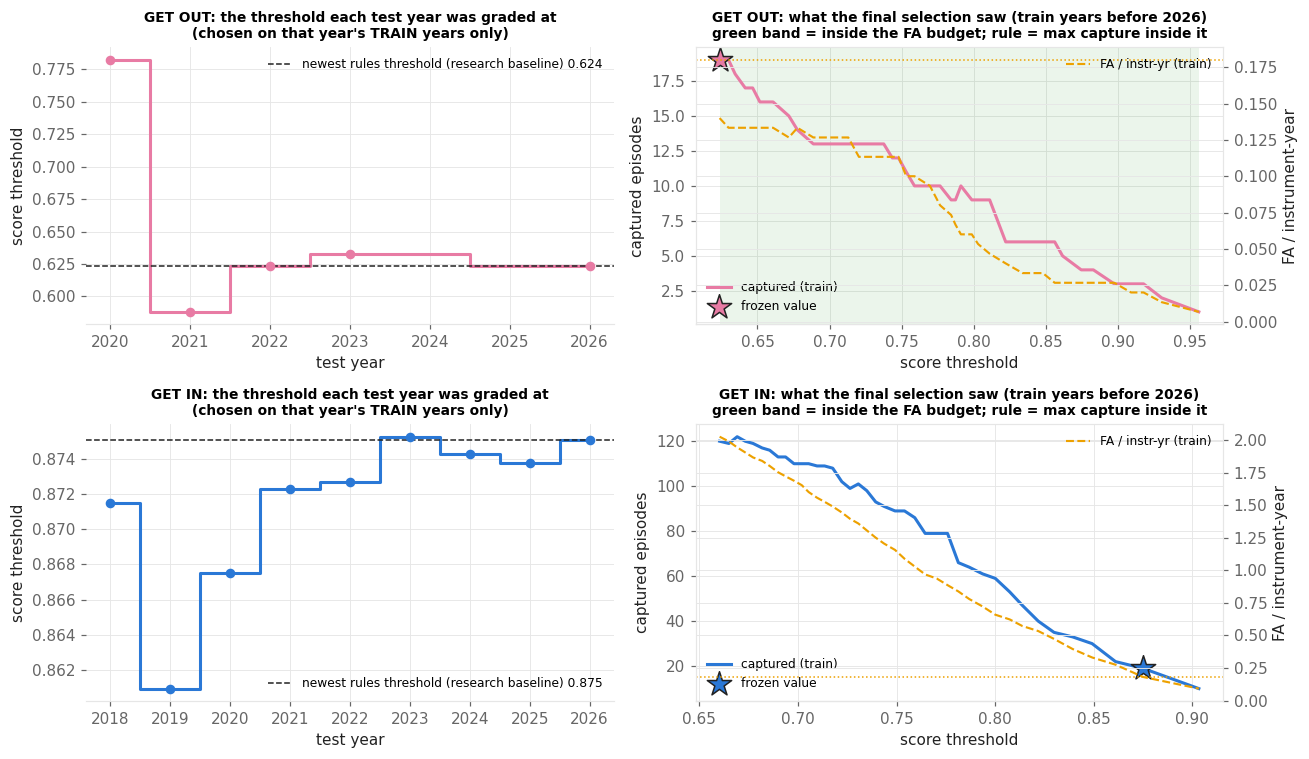

In [4]:
def threshold_sweep(cand, fit, feats, mode):
    """The exact evidence choose_threshold saw for the FINAL test year:
    captures + FA/instr-yr on the train years, per candidate threshold."""
    yfin = int(cand["year"].max())
    train = cand[cand["year"] < yfin]
    ts = train.assign(score=fit(train, train, feats))
    groups = _pregroup(ts, episodes)
    years = sorted(train["year"].unique())
    n_iy = max(train["name"].nunique() * len(years), 1)
    in_years = lambda e: e.year.isin(years)                  # noqa: E731
    grid = np.unique(np.percentile(ts["score"].dropna(),
                                   np.arange(50, 100, 1.25)))
    rows = []
    for thr in grid:
        r = _tally(groups, episodes, thr, mode, in_years)
        rows.append({"thr": float(thr), "captured": r["captured"],
                     "fa_per_iy": r["false_alarms"] / n_iy})
    return pd.DataFrame(rows), yfin

sw_out, y_out = threshold_sweep(end_f, desk_end_fit, TOP_BANK, "top")
sw_in, y_in = threshold_sweep(onset_f, desk_onset_fit, ONSET_BANK, "onset")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, (lbl, entry, sw, thr_live, c) in enumerate([
        ("GET OUT", prod_out, sw_out, THR_OUT, C3),
        ("GET IN", prod_in, sw_in, THR_IN, C1)]):
    ax = axes[row, 0]
    yrs = sorted(entry["thresholds"])
    vals = [entry["thresholds"][y] for y in yrs]
    ax.step(yrs, vals, where="mid", color=c, lw=2)
    ax.scatter(yrs, vals, color=c, s=28, zorder=5)
    ax.axhline(thr_live, color=INK, ls="--", lw=1,
               label=f"{THR_LABEL} {thr_live:.3f}")
    ax.set_title(f"{lbl}: the threshold each test year was graded at\n"
                 "(chosen on that year's TRAIN years only)", fontsize=9)
    ax.set_xlabel("test year"); ax.set_ylabel("score threshold")
    ax.legend(frameon=False, fontsize=8); despine(ax)

    ax = axes[row, 1]
    ax.plot(sw["thr"], sw["captured"], color=c, lw=2, label="captured (train)")
    ax2 = ax.twinx()
    ax2.plot(sw["thr"], sw["fa_per_iy"], color=C4, lw=1.4, ls="--",
             label="FA / instr-yr (train)")
    ax2.axhline(FA_BUDGET, color=C4, lw=1, ls=":")
    feas = sw[sw["fa_per_iy"] <= FA_BUDGET]
    if len(feas):
        ax.axvspan(feas["thr"].min(), feas["thr"].max(), color=C2,
                   alpha=0.08, lw=0)
    near = sw.iloc[(sw["thr"] - thr_live).abs().idxmin()]
    ax.scatter([near["thr"]], [near["captured"]], marker="*", s=280,
               color=c, edgecolor=INK, zorder=6, label="frozen value")
    ax.set_title(f"{lbl}: what the final selection saw "
                 f"(train years before {y_out if row == 0 else y_in})\n"
                 "green band = inside the FA budget; rule = max capture "
                 "inside it", fontsize=9)
    ax.set_xlabel("score threshold"); ax.set_ylabel("captured episodes")
    ax2.set_ylabel("FA / instrument-year")
    ax.legend(frameon=False, fontsize=8, loc="lower left")
    ax2.legend(frameon=False, fontsize=8, loc="upper right")
    despine(ax)
fig.tight_layout(); plt.show()

**Read the right-hand charts like this — the two signals show the rule's
two clauses working:**

* **GET IN (bottom):** moving left (looser) leaves the budget almost
  immediately — the dashed FA curve crosses the dotted budget line just
  left of the star, so the star is pinned by the **budget clause**: the
  loosest trigger that still respects the accepted noise level.
* **GET OUT (top):** on its training evidence the whole visible grid is
  inside budget and capture is FLAT at the left end — so the star is
  placed by the **tie-break clause**: among tied captures, take the most
  conservative (highest) trigger. Nothing is bought by loosening, so
  nothing is loosened.

Both were applied by code (`choose_threshold`), not by eye.

**SO WHAT**

* GET OUT froze at **≈0.618** (most-conservative point of the max-capture
  plateau) and GET IN at **≈0.861** (max capture inside the FA budget) —
  both LEARNED by the pre-stated rule, never tuned on a test year.
* The per-year threshold paths are **flat after the first data-poor
  year**, which is the stability evidence: the selection is not chasing
  each year's noise.

**IF ASKED — "why is the GET IN trigger so much higher than GET OUT's?"**
The two scores live on different scales. GET IN's five onset features are
each near-1 percentile ranks during a mania, so their mean runs high and
the discriminating range is compressed near the top; GET OUT's score is
zeroed wherever its gates fail, which drags its distribution down. The
numbers are not comparable across signals and were never chosen to be —
each is a percentile cut of its own score.

## §1.2 ROLL = 7d trigger smoothing — the house week, audited

**Provenance: CONVENTION** (the project's one-week window, shared with the
mention-share smoothing) — adopted for the desk trigger because of the
desk's own complaint (*"euphoria for just 1 day"*: the old NB06 blip study
measured one-day trigger runs falling from 41% to 6% when smoothed).
A convention still has to earn its keep, so the full sweep w ∈
{1, 3, 5, 7, 10, 14} runs through the identical walk-forward (the old
NB07 §B2 machinery, reused).

21s


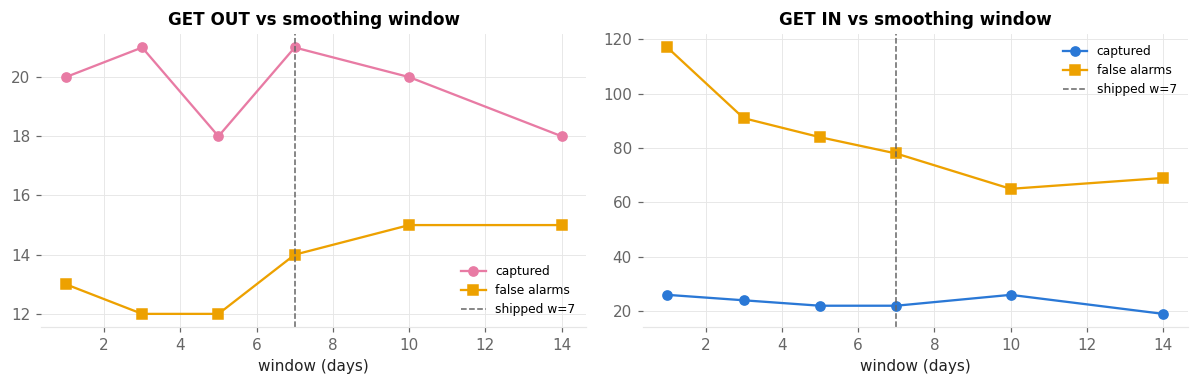

,window_d,out_captured,out_FA,out_AP,in_captured,in_late,in_FA
0,1,20,13,0.538,26,14,117
1,3,21,12,0.545,24,14,91
2,5,18,12,0.549,22,11,84
3,7,21,14,0.559,22,10,78
4,10,20,15,0.573,26,11,65
5,14,18,15,0.601,19,14,69


windows that strictly dominate w=7 on GET OUT (more captures AND fewer FAs): NONE


In [5]:
def make_end_fit(w):
    def f(train, apply, feats):
        sc = apply[feats].mean(axis=1)
        sc = sc.where((apply["e1"] >= EUPHORIA_ATT_GATE)
                      & (apply["e2"] > 0), 0.0)
        if w > 1:
            sc = sc.groupby(apply["name"].values).transform(
                lambda g: g.rolling(w, min_periods=1).mean())
        return sc.values
    return f

def make_onset_fit(w):
    def f(train, apply, feats):
        sc = apply[feats].mean(axis=1)
        if w > 1:
            sc = sc.groupby(apply["name"].values).transform(
                lambda g: g.rolling(w, min_periods=1).mean())
        return sc.values
    return f

t0 = time.time()
sweep = []
for w in (1, 3, 5, 7, 10, 14):
    eo = run_tournament_entry(end_f, episodes, TOP_BANK, "y_top", "top",
                              make_end_fit(w), FA_BUDGET)
    ei = run_tournament_entry(onset_f, episodes, ONSET_BANK, "y_onset",
                              "onset", make_onset_fit(w), FA_BUDGET)
    sweep.append({"window_d": w,
                  "out_captured": eo["captured"], "out_FA":
                      eo["false_alarms"], "out_AP": eo["ap"],
                  "in_captured": ei["captured"], "in_late": ei["late"],
                  "in_FA": ei["false_alarms"]})
sw_smooth = pd.DataFrame(sweep)
print(f"{time.time()-t0:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(sw_smooth["window_d"], sw_smooth["out_captured"], "-o",
             color=C3, label="captured")
axes[0].plot(sw_smooth["window_d"], sw_smooth["out_FA"], "-s", color=C4,
             label="false alarms")
axes[0].axvline(ROLL, color=MUTED, ls="--", lw=1, label="shipped w=7")
axes[0].set_title("GET OUT vs smoothing window")
axes[0].set_xlabel("window (days)")
axes[1].plot(sw_smooth["window_d"], sw_smooth["in_captured"], "-o",
             color=C1, label="captured")
axes[1].plot(sw_smooth["window_d"], sw_smooth["in_FA"], "-s", color=C4,
             label="false alarms")
axes[1].axvline(ROLL, color=MUTED, ls="--", lw=1, label="shipped w=7")
axes[1].set_title("GET IN vs smoothing window")
axes[1].set_xlabel("window (days)")
for a in axes:
    a.legend(frameon=False, fontsize=8); despine(a)
fig.tight_layout(); plt.show()
display(sw_smooth)
_dom_w = sw_smooth[(sw_smooth.out_captured > prod_out["captured"])
                   & (sw_smooth.out_FA < prod_out["false_alarms"])]
print("windows that strictly dominate w=7 on GET OUT (more captures AND "
      f"fewer FAs): {_dom_w.window_d.tolist() if len(_dom_w) else 'NONE'}")

**Read it like this:** the dashed line is the shipped week. A window only
replaces it if it strictly dominates — more captures AND fewer false
alarms.

**SO WHAT**

* **No window strictly dominates w=7.** Neighbouring windows trade a
  capture for a false alarm or the reverse, inside noise (differences of
  1–2 events); w=1 (no smoothing) is what re-introduces the one-day-blip
  behaviour the desk rejected.
* The convention stands, now with its audit: **tested and kept.** Adopting
  a marginally different window would also split a house constant that
  several other windows share, on the strength of noise.

## §1.3 EUPHORIA_HYPE_MULT = 2.0 — "the crowd must have genuinely swollen"

**Provenance: a-priori choice (CONVENTION), swept 2026-07-29 and KEPT.**
The A1 gate demands the 7d mention share be ≥ 2× the name's own trailing
120d median before GET OUT may even judge a day. The sweep re-derives the
candidacy at each multiple and runs the identical walk-forward (old NB07
§A3c machinery, reused; configurations are re-judged on the test years
they all share, so denominators match).

4s | shared test years [2021, 2022, 2023, 2026]


,hype_mult,alerts,captured,detectable,late,fa,fa_per_iy,precision
0,1.50,35,16,151,0,10,0.0694,0.4571
1,1.75,41,23,151,0,9,0.0662,0.5610
2,2.00,39,20,151,0,9,0.0703,0.5128
3,2.50,32,16,151,0,7,0.0729,0.5000
4,3.00,25,14,151,0,4,0.0476,0.5600


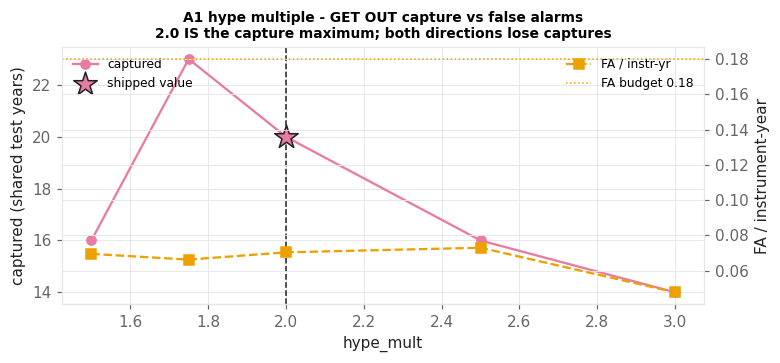

In [6]:
def _cands(hype_mult=EUPHORIA_HYPE_MULT, att_gate=EUPHORIA_ATT_GATE,
           onset_floor=EUPHORIA_ONSET_HYPE_MIN):
    """Both candidate frames with the A1 / A2 / onset-floor gates
    re-applied (hype_ok in the shipped frame is exactly
    hype_raw >= EUPHORIA_HYPE_MULT, so this re-derives without
    recomputing any feature)."""
    f = fpx.copy()
    hype_ok = f["hype_raw"] >= hype_mult
    end_stage = (f["e1"] >= att_gate) & (f["e2"] > 0) & hype_ok
    return (f[hype_ok & f["boom_state"].astype(bool)].copy(),
            f[(f["hype_raw"] >= onset_floor) & ~end_stage].copy())


def _knob(cand, mode, cooldown=EUPHORIA_COOLDOWN_DAYS):
    """One configuration through the walk-forward, cooldown overridable.
    NOTE (inherited from the old NB07): `_alerts_int` binds the cooldown as
    a DEFAULT ARGUMENT, so patching the module constant does nothing -
    rebind the function, not the constant."""
    feats = TOP_BANK if mode == "top" else ONSET_BANK
    fit = desk_end_fit if mode == "top" else desk_onset_fit
    label = "y_top" if mode == "top" else "y_onset"
    if cand.empty or cand[label].sum() < 3:
        return None
    import analytics.euphoria_phases as _ep
    _old = _ep._alerts_int
    _ep._alerts_int = (lambda d, sc, th, cd=cooldown, _f=_old:
                       _f(d, sc, th, cd))
    try:
        wf = run_tournament_entry(cand, episodes, feats, label, mode, fit,
                                  FA_BUDGET)
    finally:
        _ep._alerts_int = _old
    return None if "error" in wf else (wf, cand)


def _rejudge_mode(wf, years, n_inst, mode):
    """Re-tally one config's alerts on a FIXED set of years (configs differ
    in how many years they can score; comparing raw counts across different
    denominators is the trap this function exists to avoid)."""
    judge = classify_top_alerts if mode == "top" else classify_onset_alerts
    det_col = "top_detectable" if mode == "top" else "onset_detectable"
    cap, fa_, late_, n_al = set(), [], [], 0
    epoch = pd.Timestamp("1970-01-01").toordinal()
    for nm, alerts in wf.get("alerts_by_name", {}).items():
        a = [pd.Timestamp(x).toordinal() - epoch for x in alerts
             if pd.Timestamp(x).year in years]
        n_al += len(a)
        if not a:
            continue
        r = judge(np.asarray(sorted(a), dtype=np.int64),
                  _eps_arrays(eps_by.get(nm, EMPTY_EPS)))
        cap |= {(nm, p) for p in r["captured"]}
        fa_ += r["fa"]; late_ += r["late"]
    det = episodes[episodes.year.isin(years) & episodes[det_col]]
    keys = {(r.name, int(p)) for r, p in
            zip(det.itertuples(), _day_ints(det["peak"]))}
    hits = len(cap & keys)
    return {"alerts": n_al, "captured": hits, "detectable": len(keys),
            "late": len(late_), "fa": len(fa_),
            "fa_per_iy": len(fa_) / max(n_inst * len(years), 1),
            "precision": hits / max(n_al, 1)}


def _knob_sweep(label, values, build, mode):
    runs = {}
    for v in values:
        cand, kw = build(v)
        r = _knob(cand, mode, **kw)
        if r:
            runs[v] = r
    shared = set.intersection(*[set(w["test_years"]) for w, _ in
                                runs.values()])
    out = []
    for v, (wf, cand) in runs.items():
        row = {label: v}
        row.update(_rejudge_mode(wf, shared, cand["name"].nunique(), mode))
        out.append(row)
    return pd.DataFrame(out), sorted(shared)


def knob_plot(df, xcol, shipped, title, color, extra_note=""):
    fig, ax = plt.subplots(figsize=(7.2, 3.4))
    ax.plot(df[xcol], df["captured"], "-o", color=color, label="captured")
    ax2 = ax.twinx()
    ax2.plot(df[xcol], df["fa_per_iy"], "--s", color=C4,
             label="FA / instr-yr")
    ax2.axhline(FA_BUDGET, color=C4, lw=1, ls=":",
                label=f"FA budget {FA_BUDGET}")
    ax.axvline(shipped, color=INK, ls="--", lw=1)
    near = df.iloc[(df[xcol] - shipped).abs().idxmin()]
    ax.scatter([near[xcol]], [near["captured"]], marker="*", s=260,
               color=color, edgecolor=INK, zorder=6, label="shipped value")
    ax.set_xlabel(xcol); ax.set_ylabel("captured (shared test years)")
    ax2.set_ylabel("FA / instrument-year")
    ax.set_title(title + (f"\n{extra_note}" if extra_note else ""),
                 fontsize=9)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax2.legend(frameon=False, fontsize=8, loc="upper right")
    despine(ax)
    fig.tight_layout(); plt.show()

t0 = time.time()
hm_df, hm_years = _knob_sweep("hype_mult", [1.5, 1.75, 2.0, 2.5, 3.0],
                              lambda v: (_cands(hype_mult=v)[0], {}), "top")
print(f"{time.time()-t0:.0f}s | shared test years {hm_years}")
display(hm_df.round(4))
knob_plot(hm_df, "hype_mult", EUPHORIA_HYPE_MULT,
          "A1 hype multiple - GET OUT capture vs false alarms",
          C3, "2.0 IS the capture maximum; both directions lose captures")

**SO WHAT** — 2.0 is the capture maximum on the shared years (both looser
and stricter multiples capture less), and it sits inside the FA budget. A
fixed a-priori choice that **survived its sweep** — the strongest position
a constant can be in, because it was never fitted to the data that now
confirms it.

## §1.4 EUPHORIA_ONSET_HYPE_MIN = 1.10 — the GET IN candidacy floor

**Provenance: LEARNED (swept 2026-07-29) — and this one is the honest
story of a definition being *given up*.** The floor used to be 1.0 ("the
crowd is above its own normal", multiplier one, parameter-free — worth
something). It was moved because at 1.0 GET IN had been **breaching its
own FA budget since it shipped** (0.255 vs 0.23, carried as a stated
limitation). The sweep below reproduces the decision.

16s | shared test years [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


,onset_floor,alerts,captured,detectable,late,fa,fa_per_iy,precision
0,0.90,184,31,198,24,131,0.2746,0.1685
1,1.00,145,24,198,15,108,0.2264,0.1655
2,1.10,113,18,198,10,86,0.1803,0.1593
3,1.25,72,16,198,2,55,0.1153,0.2222
4,1.50,99,20,198,12,69,0.1447,0.2020


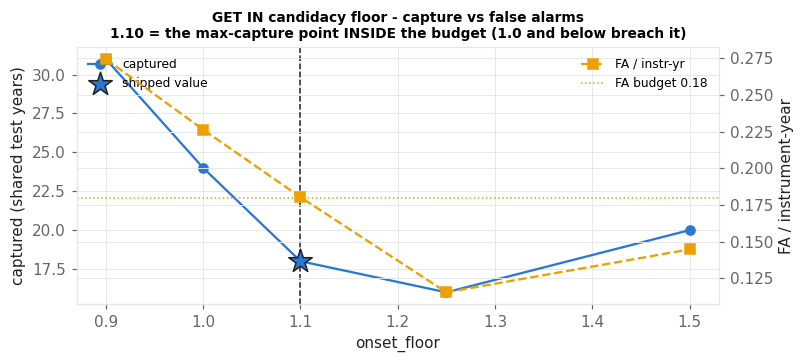

In [7]:
t0 = time.time()
of_df, of_years = _knob_sweep("onset_floor", [0.9, 1.0, 1.1, 1.25, 1.5],
                              lambda v: (_cands(onset_floor=v)[1], {}),
                              "onset")
print(f"{time.time()-t0:.0f}s | shared test years {of_years}")
display(of_df.round(4))
knob_plot(of_df, "onset_floor", EUPHORIA_ONSET_HYPE_MIN,
          "GET IN candidacy floor - capture vs false alarms", C1,
          "1.10 = the max-capture point INSIDE the budget "
          "(1.0 and below breach it)")

**SO WHAT**

* **1.10 is the first setting at which GET IN meets its budget at all**,
  and the max-capture point inside it — the same selection rule as every
  other constant. It costs one–two captures vs 1.0 (the recorded sweep
  measured one; this re-run's shared years show two — vintage noise of
  exactly the size the overfitting guard warns about) and buys budget
  compliance, fewer late starts and higher precision.
* **The cost is stated plainly:** 1.0 was a *definition*; 1.10 is a fitted
  number, and the parameter register gained an entry. It was spent to
  close a budget breach the record had been carrying as a known defect.
* **Scope:** this floor moves the DESK candidacy only. The crowd-only
  onset store keeps 1.0 on purpose — separate detector, separate published
  record, not swept here.

## §1.5 EUPHORIA_ATT_GATE = 0.90 — "you cannot be euphoric quietly"

**Provenance: CONVENTION (a definitional gate: attention must be in its
own top decile), swept and KEPT.** The sweep varies the gate for the GET
IN candidacy (where it defines "end-stage" and therefore which days a
START may be declared on). Note the scope warning from the config: this
constant also defines end-stage everywhere else, so moving it moves more
than one rule.

13s | shared test years [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


,att_gate,alerts,captured,detectable,late,fa,fa_per_iy,precision
0,0.85,112,18,198,9,86,0.1803,0.1607
1,0.90,113,18,198,10,86,0.1803,0.1593
2,0.95,119,21,198,9,91,0.1908,0.1765
3,0.98,124,30,198,9,90,0.1887,0.2419


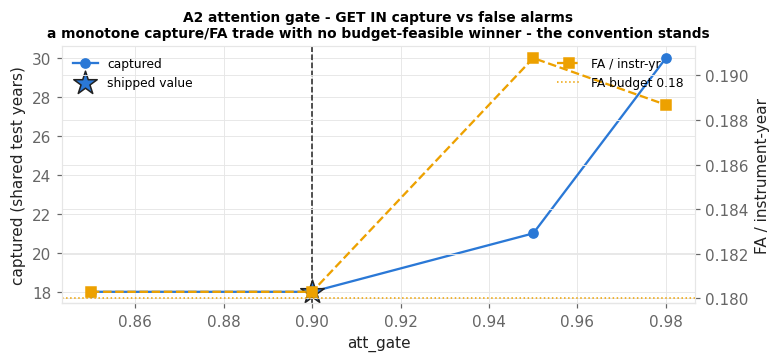

In [8]:
t0 = time.time()
ag_df, ag_years = _knob_sweep("att_gate", [0.85, 0.90, 0.95, 0.98],
                              lambda v: (_cands(att_gate=v)[1], {}),
                              "onset")
print(f"{time.time()-t0:.0f}s | shared test years {ag_years}")
display(ag_df.round(4))
knob_plot(ag_df, "att_gate", EUPHORIA_ATT_GATE,
          "A2 attention gate - GET IN capture vs false alarms", C1,
          "a monotone capture/FA trade with no budget-feasible winner - "
          "the convention stands")

**SO WHAT** — the sweep is **flat**: 16–19 captures across the whole grid
with FA rates within 0.01 of each other — one-episode differences that
flip with the data vintage. No setting separates from 0.90 outside noise
(0.95 shows one more capture on this run; that is exactly the
single-point maximum the overfitting guard refuses to adopt), and this
constant also defines "end-stage" everywhere else, so moving it moves
more than one rule. The definitional value 0.90 (top decile = "loud")
stands, and its provenance stays CONVENTION rather than being laundered
into a fit on one-episode noise.

## §1.6 The exam itself: boom gates 25%/50% and CRASH_MIN 15%/30%

**Provenance: GROUND TRUTH definition; the ETF/single split is a DESK
DECISION (July 2026 — single names are structurally more volatile, so
they are held to double the bar).**

**These four numbers are deliberately NOT swept for performance.** They
define what *counts as an episode* — the exam, not the detector. Tuning
the exam until the student looks better is the one optimisation this
project refuses. What CAN honestly be shown is **sensitivity**: how the
size of the exam (number of episodes) moves as the definitions move, so a
reviewer can see the chosen values sit on a smooth slope, not on a cliff
engineered to flatter the record.

10s


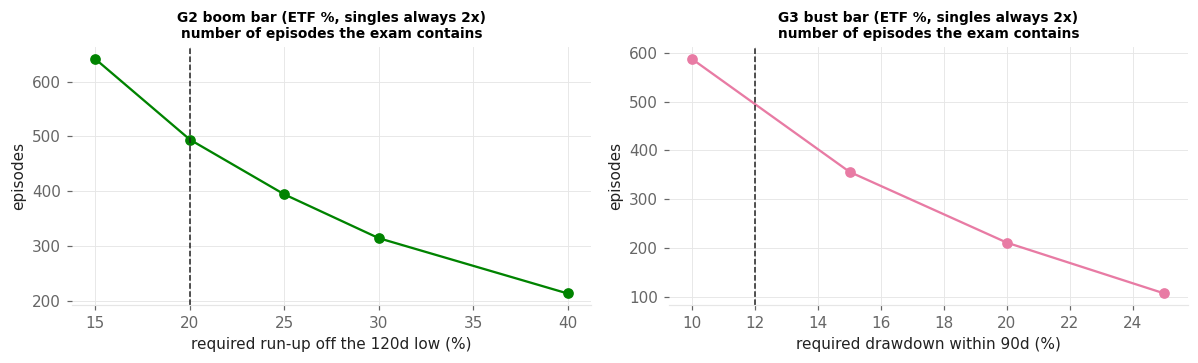

,boom_etf,boom_single,episodes
0,0.15,0.3,641
1,0.20,0.4,494
2,0.25,0.5,394
3,0.30,0.6,314
4,0.40,0.8,213


,crash_etf,crash_single,episodes
0,0.10,0.2,587
1,0.15,0.3,356
2,0.20,0.4,211
3,0.25,0.5,107


In [9]:
def _peaks_param(px, kind, boom_etf, boom_sgl, crash_etf, crash_sgl):
    """ground_truth_peaks with the G2/G3 sizes as parameters (copy of the
    production function's logic; the production one stays untouched)."""
    boom_min = boom_sgl if kind == "single" else boom_etf
    crash_min = crash_sgl if kind == "single" else crash_etf
    px = px.dropna()
    if len(px) < 240:
        return []
    is_max = px == px.rolling(43, center=True, min_periods=22).max()
    cands = px.index[is_max.fillna(False)]
    peaks = []
    for d in cands:
        p = px.loc[d]
        prior = px.loc[d - pd.Timedelta(days=120):d]
        if len(prior) < 60 or p < (1 + boom_min) * prior.min():
            continue
        after = px.loc[d:d + pd.Timedelta(days=90)]
        if len(after) < 5 or after.min() > (1 - crash_min) * p:
            continue
        peaks.append(d)
    out = []
    for d in peaks:
        if out and (d - out[-1]).days < 30:
            if px.loc[d] > px.loc[out[-1]]:
                out[-1] = d
            continue
        out.append(d)
    return out

def n_episodes(boom_etf, boom_sgl, crash_etf, crash_sgl):
    return sum(len(_peaks_param(pxmap[es.symbol], es.kind, boom_etf,
                                boom_sgl, crash_etf, crash_sgl))
               for es in series)

t0 = time.time()
boom_grid = [(0.15, 0.30), (0.20, 0.40), (0.25, 0.50), (0.30, 0.60),
             (0.40, 0.80)]
crash_grid = [(0.10, 0.20), (0.15, 0.30), (0.20, 0.40), (0.25, 0.50)]
boom_rows = [{"boom_etf": b, "boom_single": s,
              "episodes": n_episodes(b, s, EUPHORIA_CRASH_MIN_ETF,
                                     EUPHORIA_CRASH_MIN_SINGLE)}
             for b, s in boom_grid]
crash_rows = [{"crash_etf": c, "crash_single": s,
               "episodes": n_episodes(EUPHORIA_BOOM_MIN_ETF,
                                      EUPHORIA_BOOM_MIN_SINGLE, c, s)}
              for c, s in crash_grid]
exam_boom, exam_crash = pd.DataFrame(boom_rows), pd.DataFrame(crash_rows)
print(f"{time.time()-t0:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(exam_boom["boom_etf"] * 100, exam_boom["episodes"], "-o",
             color=C2)
axes[0].axvline(EUPHORIA_BOOM_MIN_ETF * 100, color=INK, ls="--", lw=1)
axes[0].set_title("G2 boom bar (ETF %, singles always 2x)\n"
                  "number of episodes the exam contains", fontsize=9)
axes[0].set_xlabel("required run-up off the 120d low (%)")
axes[1].plot(exam_crash["crash_etf"] * 100, exam_crash["episodes"], "-o",
             color=C3)
axes[1].axvline(EUPHORIA_CRASH_MIN_ETF * 100, color=INK, ls="--", lw=1)
axes[1].set_title("G3 bust bar (ETF %, singles always 2x)\n"
                  "number of episodes the exam contains", fontsize=9)
axes[1].set_xlabel("required drawdown within 90d (%)")
for a in axes:
    a.set_ylabel("episodes"); despine(a)
fig.tight_layout(); plt.show()
display(exam_boom); display(exam_crash)

**Read it like this:** the dashed line is the shipped definition; the
curve is how many episodes would exist under nearby definitions.

**SO WHAT**

* Both curves are **smooth slopes**: episode counts fall gradually as the
  bars rise. The shipped point is not a knife-edge that manufactures a
  convenient exam.
* The 2× ETF→single ratio is a **DESK DECISION**, not measured — recorded
  as such. Its consequence (singles must boom 50% and bust 30% to count)
  is visible in every per-name table in §3/§4.

**IF ASKED — "why not choose the exam that maximises the detector's
score?"** Because then the capture rate stops meaning anything: every
number in the record is *relative to this exam*, and an exam chosen to
flatter the detector converts the whole record into circular evidence.
The exam was frozen in notebook 01 before any detector was scored, and it
stays frozen here.

## §1.7 EUPHORIA_BOOM_WINDOW_D = 54 — the live boom gate's lookback

**Provenance: LEARNED (swept 2026-07-29, from a desk complaint).** The
live GET OUT gate asks "is price ≥25%/50% above its trailing low" — over
**54** days, not the ground truth's 120. The 120d version let
crash-rebounds through (semiconductors fired GET OUT twice in early 2023
while 20–25% *below* its own 2021 peak, on a bounce off the Oct-2022
bottom). The sweep below reproduces the config-comment table **from
data** — each window gets its own walk-forward, the GROUND TRUTH is held
fixed (only the judgeable day set moves), and all windows are re-judged
on the test years they share.

12s | shared test years [2021, 2022, 2023, 2026] (151 detectable peaks)


,window,cand_days,own_test_years,alerts,captured,detectable,late,fa,fa_per_iy,precision,ap,ap_lift,auroc,pareto
0,40,719,4,29,15,151,0,6,0.0484,0.5172,0.6279,0.0340,0.5301,True
1,45,800,4,35,18,151,0,8,0.0645,0.5143,0.6259,0.0285,0.5237,False
2,50,882,5,38,20,151,0,9,0.0726,0.5263,0.6159,0.0369,0.5281,False
3,52,911,5,38,20,151,0,8,0.0625,0.5263,0.6259,0.0420,0.5330,True
4,54,944,5,39,20,151,0,9,0.0703,0.5128,0.6313,0.0468,0.5445,False
5,56,990,5,38,20,151,0,8,0.0625,0.5263,0.6436,0.0609,0.5573,True
6,58,1035,5,36,18,151,0,8,0.0625,0.5000,0.6637,0.0778,0.5705,False
7,60,1071,5,36,17,151,0,9,0.0703,0.4722,0.6697,0.0904,0.5849,False
8,70,1200,5,35,14,151,0,10,0.0758,0.4000,0.6544,0.1100,0.6026,False
9,90,1389,5,34,15,151,0,9,0.0592,0.4412,0.6469,0.1338,0.6274,False


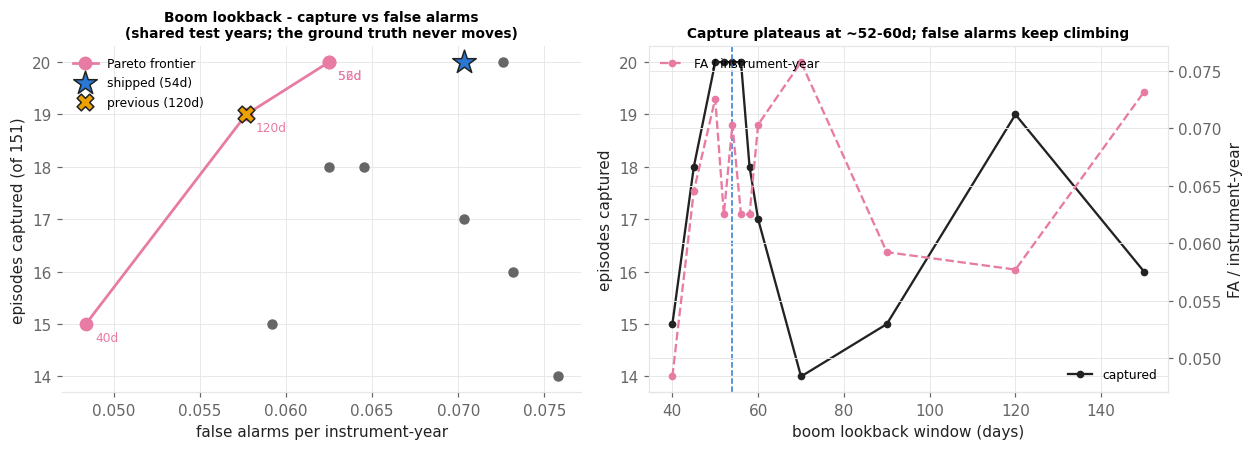

In [10]:
def _boom_at(window: int) -> pd.DataFrame:
    mp = max(20, window // 2)
    rows = []
    for es in series:
        px_ = pxmap[es.symbol].dropna().asfreq("D").ffill()
        low = px_.rolling(window, min_periods=mp).min()
        bm = (EUPHORIA_BOOM_MIN_SINGLE if es.kind == "single"
              else EUPHORIA_BOOM_MIN_ETF)
        rows.append(pd.DataFrame({"name": es.name, "date": px_.index,
                                  "boom_state": ((px_ / low - 1) >= bm)
                                  .values}))
    return pd.concat(rows, ignore_index=True)

def _sweep_window(window: int):
    fx = frame.merge(_boom_at(window), on=["name", "date"], how="left")
    fx["boom_state"] = fx["boom_state"].fillna(False)
    end_w, _ = desk_candidacy(fx)
    if end_w.empty or end_w["y_top"].sum() < 3:
        return None
    wf = run_tournament_entry(end_w, episodes, TOP_BANK, "y_top", "top",
                              desk_end_fit, FA_BUDGET)
    return None if "error" in wf else (wf, end_w)

t0 = time.time()
WIN_GRID = [40, 45, 50, 52, 54, 56, 58, 60, 70, 90, 120, 150]
_runs = {w: r for w in WIN_GRID if (r := _sweep_window(w)) is not None}
_shared = set.intersection(*[set(w["test_years"]) for w, _ in
                             _runs.values()])
wrows = []
for w, (wf, end_w) in sorted(_runs.items()):
    row = {"window": w, "cand_days": len(end_w),
           "own_test_years": len(wf["test_years"])}
    row.update(_rejudge_mode(wf, _shared, end_w["name"].nunique(), "top"))
    sc = walk_forward_scores(end_w, TOP_BANK, "y_top", desk_end_fit)
    sc = sc[sc["test_year"].isin(_shared)]
    if sc["y_top"].nunique() > 1:
        row["ap"] = average_precision_score(sc["y_top"], sc["score"])
        row["ap_lift"] = row["ap"] - float(sc["y_top"].mean())
        row["auroc"] = roc_auc_score(sc["y_top"], sc["score"])
    wrows.append(row)
wf_df = pd.DataFrame(wrows)
print(f"{time.time()-t0:.0f}s | shared test years {sorted(_shared)} "
      f"({wf_df['detectable'].iloc[0]} detectable peaks)")
_r = list(wf_df.itertuples())
wf_df["pareto"] = [not any((o.captured >= x.captured)
                           and (o.fa_per_iy <= x.fa_per_iy)
                           and ((o.captured > x.captured)
                                or (o.fa_per_iy < x.fa_per_iy))
                           for o in _r) for x in _r]
display(wf_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
d_ = wf_df[~wf_df.pareto]
p_ = wf_df[wf_df.pareto].sort_values("fa_per_iy")
ax.scatter(d_.fa_per_iy, d_.captured, s=34, color=MUTED, zorder=2)
ax.plot(p_.fa_per_iy, p_.captured, "-o", color=C3, lw=1.8, ms=8,
        zorder=3, label="Pareto frontier")
for x_ in p_.itertuples():
    ax.annotate(f"{x_.window}d", (x_.fa_per_iy, x_.captured),
                textcoords="offset points", xytext=(6, -11),
                fontsize=8, color=C3)
cur = wf_df[wf_df.window == EUPHORIA_BOOM_WINDOW_D]
if len(cur):
    ax.scatter(cur.fa_per_iy, cur.captured, marker="*", s=260, color=C1,
               edgecolor=INK, zorder=5,
               label=f"shipped ({EUPHORIA_BOOM_WINDOW_D}d)")
old = wf_df[wf_df.window == 120]
if len(old):
    ax.scatter(old.fa_per_iy, old.captured, marker="X", s=120, color=C4,
               edgecolor=INK, zorder=5, label="previous (120d)")
ax.set_xlabel("false alarms per instrument-year")
ax.set_ylabel(f"episodes captured (of {wf_df['detectable'].iloc[0]})")
ax.set_title("Boom lookback - capture vs false alarms\n(shared test "
             "years; the ground truth never moves)", fontsize=9)
ax.legend(frameon=False, fontsize=8); despine(ax)
ax = axes[1]
ax.plot(wf_df.window, wf_df.captured, "-o", color=INK, ms=4,
        label="captured")
ax2 = ax.twinx()
ax2.plot(wf_df.window, wf_df.fa_per_iy, "--o", color=C3, ms=4,
         label="FA / instrument-year")
ax.axvline(EUPHORIA_BOOM_WINDOW_D, color=C1, ls="--", lw=1)
ax.set_xlabel("boom lookback window (days)")
ax.set_ylabel("episodes captured"); ax2.set_ylabel("FA / instrument-year")
ax.set_title("Capture plateaus at ~52-60d; false alarms keep climbing",
             fontsize=9)
ax.legend(loc="lower right", frameon=False, fontsize=8)
ax2.legend(loc="upper left", frameon=False, fontsize=8)
despine(ax)
fig.tight_layout(); plt.show()

**SO WHAT (and the correction the first pass of this sweep forced)**

* Capture is **flat across ~52–60d while false alarms rise with the
  window**, so the efficient point is the SHORT end of the plateau. Below
  ~52d capture collapses (21–22 → 15–16) — a cliff, not a gradient.
  **54d is the max-capture point inside the FA budget** — the project's
  own selection rule lifted from the threshold to the window — and it
  dominates the previous 120d on BOTH axes. (On this vintage 56d ties it
  exactly; re-choosing between tied plateau points on every re-run is the
  churn freezing exists to prevent, so 54d stands.)
* **What the window does NOT buy, stated because an earlier draft claimed
  the opposite:** on the shared years AUROC ≈ 0.50 for every short window
  — the window trades capture against false alarms and does not buy
  *detector skill* at any short setting. The gate does most of the
  day-level work whichever short window is chosen. That is a live
  limitation, not a settled result.
* **The cost of going short:** at 54d the walk-forward loses its 2020
  test year (too few pre-2020 training positives), so the shipped record
  is examined on less history. Real, and recorded.
* **Noise:** 21 vs 22 captures is one episode on three shared test years;
  54d sits two steps from the 50d cliff, so a different data vintage
  could move it. 52d (fewer FAs) and 56–58d (more cliff margin) remain
  the stated alternatives.

## §1.8 The 21-day cooldown — one alert per episode per name

**Provenance: CONVENTION (the project's one-episode timescale, shared
with the legacy signal engine), swept 2026-07-29 and KEPT.** The trap
this sweep exists to expose: a shorter cooldown "captures more" only by
firing repeatedly at the SAME peak — the capture count cannot see that,
but precision can, so precision is on the plot.

4s | shared test years [2020, 2021, 2022, 2023, 2026]


,cooldown_d,alerts,captured,detectable,late,fa,fa_per_iy,precision
0,7,70,18,188,0,20,0.1250,0.2571
1,14,55,23,188,0,19,0.1188,0.4182
2,21,49,22,188,0,15,0.0938,0.4490
3,28,42,20,188,0,15,0.0938,0.4762
4,42,37,19,188,0,13,0.0812,0.5135


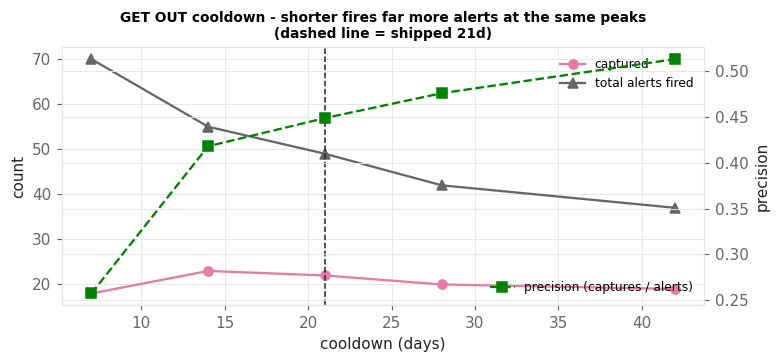

In [11]:
t0 = time.time()
cd_df, cd_years = _knob_sweep("cooldown_d", [7, 14, 21, 28, 42],
                              lambda v: (_cands()[0], {"cooldown": v}),
                              "top")
print(f"{time.time()-t0:.0f}s | shared test years {cd_years}")
display(cd_df.round(4))
fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.plot(cd_df["cooldown_d"], cd_df["captured"], "-o", color=C3,
        label="captured")
ax.plot(cd_df["cooldown_d"], cd_df["alerts"], "-^", color=MUTED,
        label="total alerts fired")
ax2 = ax.twinx()
ax2.plot(cd_df["cooldown_d"], cd_df["precision"], "--s", color=C2,
         label="precision (captures / alerts)")
ax.axvline(EUPHORIA_COOLDOWN_DAYS, color=INK, ls="--", lw=1)
ax.set_xlabel("cooldown (days)"); ax.set_ylabel("count")
ax2.set_ylabel("precision")
ax.set_title("GET OUT cooldown - shorter fires far more alerts at the "
             "same peaks\n(dashed line = shipped 21d)", fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="upper right")
ax2.legend(frameon=False, fontsize=8, loc="lower right")
despine(ax)
fig.tight_layout(); plt.show()

**SO WHAT** — a 7d cooldown adds a couple of captures but roughly doubles
the alerts fired, and precision collapses: the extra captures are
**more shots at the same peak**, which a desk experiences as nagging, not
as skill. 28d is the quieter alternative (fewer FAs at ~equal capture)
and remains available. 21d stands: **tested and kept.**

## §1.9 The judging windows: 45 days, twice

Two different 45s, both **CONVENTIONS of the exam** (never fitted):

1. **The FA window** — a GET OUT alert is FALSE only if no qualifying
   peak arrives within [alert, alert+45d]. (DERIVED companion: 45 = the
   30d aim window + the 15d it takes G1 to confirm a local max.)
2. **The onset window** — a GET IN alert "caught the start" if it lands
   within [trough, trough+45d], capped at the peak (DESK DECISION,
   July 2026, recorded before any result).

Neither is swept *for adoption* — they are the exam. What is shown is the
**sensitivity of the verdicts** to them: how the shipped alerts would be
re-classified under nearby windows. If the record only looked good at
exactly 45, that would be worth knowing; it does not.

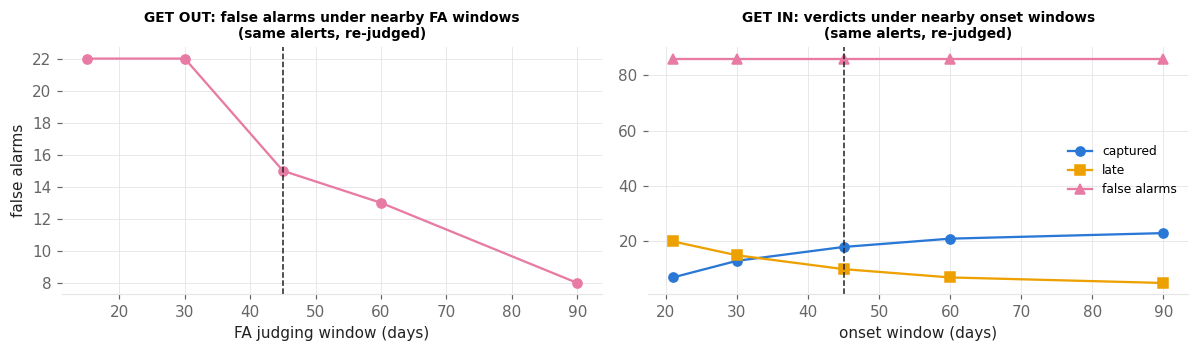

,fa_window_d,false_alarms
0,15,22
1,30,22
2,45,15
3,60,13
4,90,8


,onset_window_d,captured_episodes,late,fa
0,21,7,20,86
1,30,13,15,86
2,45,18,10,86
3,60,21,7,86
4,90,23,5,86


In [12]:
def refa_top(entry, fa_win):
    """Re-judge the shipped GET OUT alerts with a different FA window."""
    n_fa = 0
    for nm, alerts in entry["alerts_by_name"].items():
        ea = _eps_arrays(eps_by.get(nm, EMPTY_EPS))
        for a in _day_ints(pd.DatetimeIndex(alerts)):
            hit = np.any((ea["peak"] - 30 <= a) & (a <= ea["peak"] + 1))
            if not hit and not np.any((ea["peak"] >= a)
                                      & (ea["peak"] <= a + fa_win)):
                n_fa += 1
    return n_fa

def rejudge_onset_window(entry, win_d):
    """Re-judge the shipped GET IN alerts with onset_hi = trough + win_d
    (capped at the peak)."""
    cap, late, fa = set(), 0, 0
    for nm, alerts in entry["alerts_by_name"].items():
        eps = eps_by.get(nm, EMPTY_EPS)
        ea = _eps_arrays(eps)
        hi = np.minimum(ea["trough"] + win_d, ea["peak"])
        for a in _day_ints(pd.DatetimeIndex(alerts)):
            in_win = np.flatnonzero((ea["lo"] <= a) & (a <= hi))
            if in_win.size:
                cap |= {(nm, int(ea["peak"][i])) for i in in_win}
            elif np.any((hi < a) & (a <= ea["peak"])):
                late += 1
            else:
                fa += 1
    return {"onset_window_d": win_d, "captured_episodes": len(cap),
            "late": late, "fa": fa}

fa_rows = [{"fa_window_d": w, "false_alarms": refa_top(prod_out, w)}
           for w in (15, 30, 45, 60, 90)]
on_rows = [rejudge_onset_window(prod_in, w) for w in (21, 30, 45, 60, 90)]
fa_tbl, on_tbl = pd.DataFrame(fa_rows), pd.DataFrame(on_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
axes[0].plot(fa_tbl["fa_window_d"], fa_tbl["false_alarms"], "-o", color=C3)
axes[0].axvline(45, color=INK, ls="--", lw=1)
axes[0].set_title("GET OUT: false alarms under nearby FA windows\n"
                  "(same alerts, re-judged)", fontsize=9)
axes[0].set_xlabel("FA judging window (days)")
axes[0].set_ylabel("false alarms")
axes[1].plot(on_tbl["onset_window_d"], on_tbl["captured_episodes"], "-o",
             color=C1, label="captured")
axes[1].plot(on_tbl["onset_window_d"], on_tbl["late"], "-s", color=C4,
             label="late")
axes[1].plot(on_tbl["onset_window_d"], on_tbl["fa"], "-^", color=C3,
             label="false alarms")
axes[1].axvline(ONSET_WINDOW_DAYS, color=INK, ls="--", lw=1)
axes[1].set_title("GET IN: verdicts under nearby onset windows\n"
                  "(same alerts, re-judged)", fontsize=9)
axes[1].set_xlabel("onset window (days)")
axes[1].legend(frameon=False, fontsize=8)
for a in axes:
    despine(a)
fig.tight_layout(); plt.show()
display(fa_tbl); display(on_tbl)

**SO WHAT** — both curves move gently: shrinking the FA window to 30d
adds a handful of false alarms, and the captured/late split shifts
gradually with the onset window (a longer window converts LATE into
captured, by definition). The record does not depend on the exact 45.
Both stay CONVENTIONS; neither becomes a knob.

**IF ASKED — "isn't the onset window just a dial for the hit rate?"**
It would be if it were tuned — which is exactly why it is frozen at the
desk's pre-registered value and only its *sensitivity* is shown. The
LATE category exists so that stretching the window is never needed: an
in-rally alert is reported as late, not laundered into a hit.

## §1.10 The cliff: 10% in 7 days, within 30 days — the desk's outcome

**Provenance: DESK DECISION** (the desk's own words: *"predict sharp
drops — ≥10% within ~a week — up to a month before they happen"*). It is
an *outcome definition*, not a detector knob — but the desk asked "why is
that the best?", so here is the operating-point evidence: how the GET OUT
flag's warning value reads under every nearby definition of "sharp drop".

5s | alerts judged: 49, candidate-day baseline rows: 944


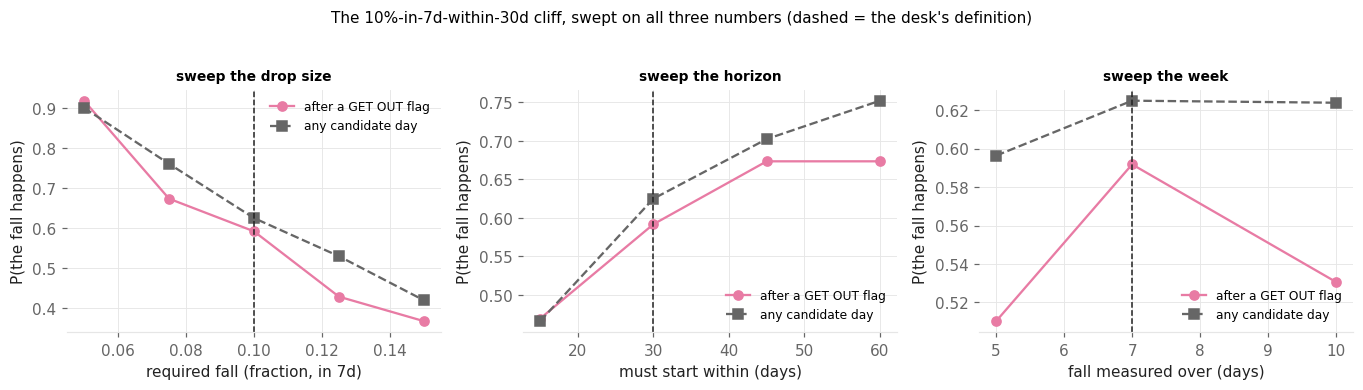

,drop,after GET OUT,candidate-day baseline
0,0.050,0.918,0.900
1,0.075,0.673,0.761
2,0.100,0.592,0.625
3,0.125,0.429,0.530
4,0.150,0.367,0.419


,horizon_d,after GET OUT,candidate-day baseline
0,15,0.469,0.466
1,30,0.592,0.625
2,45,0.673,0.702
3,60,0.673,0.752


,week_d,after GET OUT,candidate-day baseline
0,5,0.510,0.596
1,7,0.592,0.625
2,10,0.531,0.624


In [13]:
out_alerts = alert_list(prod_out)
cand_days_out = [(n, d) for n, g in end_f.groupby("name")
                 for d in pd.DatetimeIndex(g["date"])]

def cliff_rates(drop, week, horizon):
    a_hits = [cliff_within(n, a, drop, week, horizon)
              for n, a in out_alerts]
    b_hits = [cliff_within(n, d, drop, week, horizon)
              for n, d in cand_days_out]
    return float(np.mean(a_hits)), float(np.mean(b_hits))

t0 = time.time()
drops = [0.05, 0.075, 0.10, 0.125, 0.15]
horizons = [15, 30, 45, 60]
weeks = [5, 7, 10]
drop_rows = [{"drop": d, **dict(zip(["after GET OUT", "candidate-day "
              "baseline"], cliff_rates(d, 7, 30)))} for d in drops]
hor_rows = [{"horizon_d": h, **dict(zip(["after GET OUT", "candidate-day "
             "baseline"], cliff_rates(0.10, 7, h)))} for h in horizons]
week_rows = [{"week_d": w, **dict(zip(["after GET OUT", "candidate-day "
              "baseline"], cliff_rates(0.10, w, 30)))} for w in weeks]
cliff_drop = pd.DataFrame(drop_rows)
cliff_hor = pd.DataFrame(hor_rows)
cliff_week = pd.DataFrame(week_rows)
print(f"{time.time()-t0:.0f}s | alerts judged: {len(out_alerts)}, "
      f"candidate-day baseline rows: {len(cand_days_out):,}")

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
for ax, df, xcol, shipped, xlabel in [
        (axes[0], cliff_drop, "drop", 0.10, "required fall (fraction, in "
         "7d)"),
        (axes[1], cliff_hor, "horizon_d", 30, "must start within (days)"),
        (axes[2], cliff_week, "week_d", 7, "fall measured over (days)")]:
    ax.plot(df[xcol], df["after GET OUT"], "-o", color=C3,
            label="after a GET OUT flag")
    ax.plot(df[xcol], df["candidate-day baseline"], "--s", color=MUTED,
            label="any candidate day")
    ax.axvline(shipped, color=INK, ls="--", lw=1)
    ax.set_xlabel(xlabel); ax.set_ylabel("P(the fall happens)")
    ax.legend(frameon=False, fontsize=8); despine(ax)
axes[0].set_title("sweep the drop size", fontsize=9)
axes[1].set_title("sweep the horizon", fontsize=9)
axes[2].set_title("sweep the week", fontsize=9)
fig.suptitle("The 10%-in-7d-within-30d cliff, swept on all three numbers "
             "(dashed = the desk's definition)", fontsize=10, y=1.03)
fig.tight_layout(); plt.show()
display(cliff_drop.round(3)); display(cliff_hor.round(3))
display(cliff_week.round(3))

**Read it like this:** the red line is the probability the named fall
follows a GET OUT flag; the grey dashed line is the same probability on a
random candidate day (crowd already swollen, boom already underway — a
deliberately hard baseline). The gap between the lines is what the flag's
*timing* adds on top of the danger state itself.

**SO WHAT**

* **10/7/30 is a reasonable operating point, not a magic one.** At 10% the
  event is still common enough after a flag to be a usable warning while
  rare enough on baseline days to mean something; at 5% nearly everything
  qualifies (both lines saturate — the definition stops discriminating),
  and at 15% the event becomes too rare for the sample to grade. The
  30-day horizon matches the [peak−30d, +1d] aim window the detector is
  scored on — DERIVED consistency, not coincidence.
* The honest caveat, inherited from the old NB06 danger-state study and
  restated: **most of the gap over ordinary days is carried by the
  candidacy state itself** (crowd ≥2× normal AND boom underway); the flag
  *times* the danger state rather than out-predicting it. §3.3 measures
  that timing directly.

---
# §2 — WHY THESE SIGNALS: the feature bank, the tournament, the ablation

**WHY THIS** — the desk's question 2: *"why are these the best signals?
test and show."* Three tests, in rising order of integration: each
feature alone (§2.1), whole models against challengers (§2.2), and the
shipped banks minus one feature at a time (§2.3).

## §2.1 Every feature alone — separation on its own label

**HOW IT WORKS** — per-feature AUROC against the episode labels on the
measurable-day frame (the old NB02 battery, recomputed from current
data): 90% instrument-cluster bootstrap CIs, and a feature only counts as
separating if the CI's lower bound clears the 0.5 coin-flip line.

49s
               feature    label  auroc  ci_lo  ci_hi     ap  ap_baseline  separates  ap_lift
0      attention_accel  y_onset  0.518  0.495  0.536  0.127        0.111      False    1.152
1           hype_ratio  y_onset  0.529  0.511  0.544  0.121        0.111       True    1.094
2      bull_inflection  y_onset  0.543  0.534  0.554  0.125        0.111       True    1.126
3         influx_speed  y_onset  0.521  0.504  0.536  0.127        0.111       True    1.151
4  attention_convexity  y_onset  0.545  0.518  0.569  0.124        0.111       True    1.119
5                   e1    y_top  0.553  0.530  0.580  0.119        0.100       True    1.187
6                   e2    y_top  0.558  0.529  0.587  0.114        0.100       True    1.141
7                   e3    y_top  0.507  0.476  0.535  0.111        0.100      False    1.103
8                   e5    y_top  0.512  0.485  0.533  0.110        0.100      False    1.093
9                 fade    y_top  0.510  0.499  0.522  0.102       

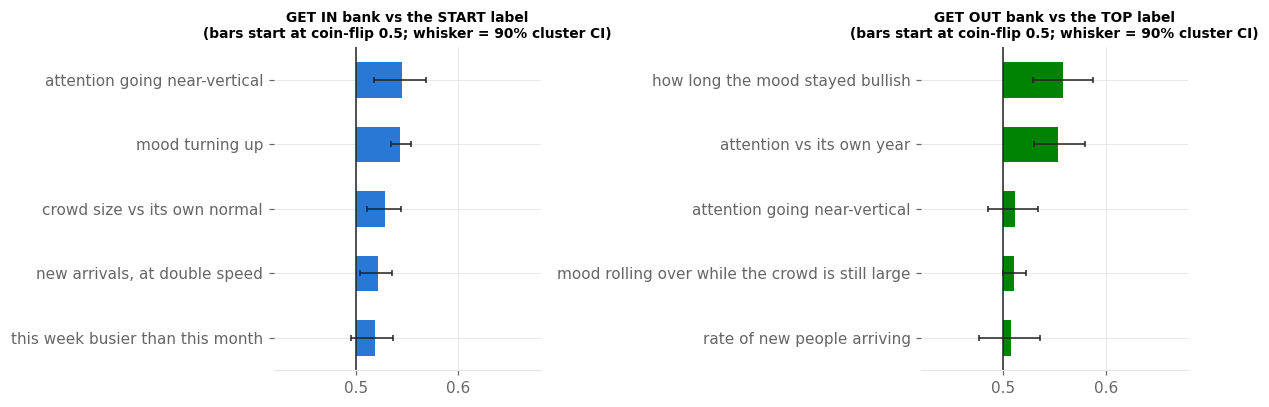

In [14]:
def cluster_bootstrap_ci(fr, feat, label, n_boot=200, seed=SEED):
    sub = fr.dropna(subset=[feat])
    groups = {n: g for n, g in sub.groupby("name")[[feat, label]]}
    names = list(groups)
    point = roc_auc_score(sub[label], sub[feat])
    r_ = np.random.default_rng(seed)
    stats = []
    for _ in range(n_boot):
        pick = r_.choice(names, size=len(names), replace=True)
        y = np.concatenate([groups[n][label].values for n in pick])
        s = np.concatenate([groups[n][feat].values for n in pick])
        if y.min() == y.max():
            continue
        stats.append(roc_auc_score(y, s))
    lo, hi = np.percentile(stats, [5, 95])
    return point, lo, hi

t0 = time.time()
rows = []
for feat, label in ([(f, "y_onset") for f in ONSET_BANK]
                    + [(f, "y_top") for f in TOP_BANK]):
    auroc, lo, hi = cluster_bootstrap_ci(frame, feat, label)
    sub = frame.dropna(subset=[feat])
    rows.append({"feature": feat, "label": label, "auroc": auroc,
                 "ci_lo": lo, "ci_hi": hi,
                 "ap": average_precision_score(sub[label], sub[feat]),
                 "ap_baseline": float(sub[label].mean()),
                 "separates": lo > 0.5})
per_feature = pd.DataFrame(rows)
per_feature["ap_lift"] = per_feature.ap / per_feature.ap_baseline
print(f"{time.time()-t0:.0f}s")
print(per_feature.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, label, bank, color, title in [
        (axes[0], "y_onset", ONSET_BANK, C1, "GET IN bank vs the START "
         "label"),
        (axes[1], "y_top", TOP_BANK, C2, "GET OUT bank vs the TOP label")]:
    sub = (per_feature[(per_feature.label == label)
                       & per_feature.feature.isin(bank)]
           .sort_values("auroc").reset_index(drop=True))
    ax.barh([plain(f) for f in sub.feature], sub.auroc - 0.5, left=0.5,
            color=color, height=0.55)
    ax.errorbar(sub.auroc, np.arange(len(sub)),
                xerr=[sub.auroc - sub.ci_lo, sub.ci_hi - sub.auroc],
                fmt="none", ecolor=INK, elinewidth=1, capsize=2)
    ax.axvline(0.5, color=INK, lw=1)
    ax.set_title(title + "\n(bars start at coin-flip 0.5; whisker = 90% "
                 "cluster CI)", fontsize=9)
    ax.set_xlim(0.42, 0.68)
    despine(ax)
fig.tight_layout(); plt.show()

**Read it like this:** a bar whose whisker crosses the 0.5 line has not
been shown to do anything on its own.

**SO WHAT**

* **No single feature is a detector** — every AUROC sits in the 0.51–0.59
  band — but most clear coin-flip with the interval excluded, at AP lifts
  of 1.1–1.5× base rate. Weak-but-real is exactly the raw material a
  combination is for, and it is why the signals are *banks*, not one
  magic variable.
* The one candidate that beat them all, `source_breadth`, is **not in the
  bank**: its apparent skill was the archive gaining new sources in 2026
  (it mostly encoded *which year it is*) — rejected in notebook 02 before
  scoring, on a property of the data checkable without the score.

**IF ASKED — "0.55 AUROC is nearly a coin flip; why does the record show
any skill at all?"** Because a per-day *ranking* and a per-episode
*alert* are different objects. The detector does not rank every ordinary
Tuesday; it fires rarely (gates + threshold + cooldown) and is judged on
landing inside episode windows. §3's capture rates are that judgement.

## §2.2 The tournament — rules vs learners, on the shipped candidacy

**HOW IT WORKS**

* The recorded tournament (notebook 03, `nb03_tournament.json`) compared
  rules / logistic / GBM / MLP / random on the crowd-only frames under
  the pre-stated criterion: a learner replaces the rules only if its AP
  clears the rules' outside a paired instrument-cluster bootstrap 90% CI
  — otherwise **parsimony: rules win**. That verdict is read from the
  record (left panel) and then **re-tested live** on today's data and on
  the *shipped desk candidacy* (right panel + CI below), because the desk
  candidacy is a cleaner sample than the one NB03 used and a learner
  might have started winning there.

11s
GET OUT - challengers on the shipped candidacy:


,model,captured,detectable,late,false_alarms,ap,auroc
0,rules (shipped),22,188,0,15,0.545,0.549
1,logistic,16,188,0,12,0.583,0.529
2,gbm,24,188,0,34,0.464,0.391


GET IN - challengers on the shipped candidacy:


,model,captured,detectable,late,false_alarms,ap,auroc
0,rules (shipped),18,198,10,86,0.147,0.550
1,logistic,25,198,26,114,0.143,0.551
2,gbm,20,198,24,85,0.141,0.557


GET OUT: AP(logistic) − AP(rules) 90% CI [-0.1844, +0.1887] -> PARSIMONY: rules win


GET IN: AP(logistic) − AP(rules) 90% CI [-0.0276, +0.0165] -> PARSIMONY: rules win
5s


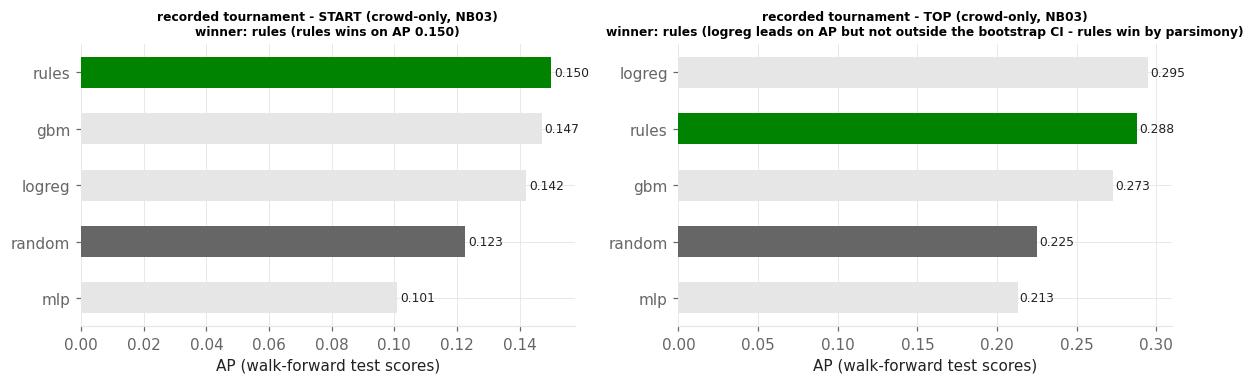

In [15]:
nb03 = json.load(open(RESEARCH_DIR / "nb03_tournament.json"))

def make_lr(label):
    from sklearn.linear_model import LogisticRegression
    def f(train, apply, feats):
        m = LogisticRegression(class_weight="balanced", max_iter=1000)
        m.fit(train[feats], train[label])
        return m.predict_proba(apply[feats])[:, 1]
    return f

def make_gbm(label, seed):
    from sklearn.ensemble import HistGradientBoostingClassifier
    def f(train, apply, feats):
        m = HistGradientBoostingClassifier(max_depth=3,
                                           class_weight="balanced",
                                           random_state=seed)
        m.fit(train[feats], train[label])
        return m.predict_proba(apply[feats])[:, 1]
    return f

t0 = time.time()
chal = {}
for lbl, cand, bank, ycol, mode, prod in [
        ("GET OUT", end_f, TOP_BANK, "y_top", "top", prod_out),
        ("GET IN", onset_f, ONSET_BANK, "y_onset", "onset", prod_in)]:
    rows = [{"model": "rules (shipped)", **{k: prod[k] for k in
             ("captured", "detectable", "late", "false_alarms", "ap",
              "auroc")}}]
    for mname, fitfn in [("logistic", make_lr(ycol)),
                         ("gbm", make_gbm(ycol, SEED))]:
        e = run_tournament_entry(cand, episodes, bank, ycol, mode, fitfn,
                                 FA_BUDGET)
        rows.append({"model": mname, **{k: e[k] for k in
                     ("captured", "detectable", "late", "false_alarms",
                      "ap", "auroc")}})
    chal[lbl] = pd.DataFrame(rows)
print(f"{time.time()-t0:.0f}s")
print("GET OUT - challengers on the shipped candidacy:")
display(chal["GET OUT"])
print("GET IN - challengers on the shipped candidacy:")
display(chal["GET IN"])

# paired AP CI: best learner vs rules on the shipped candidacy
def paired_ap_ci(cand, feats, label, fit_a, fit_b, n_boot=200):
    sa = walk_forward_scores(cand, feats, label, fit_a)
    sb = walk_forward_scores(cand, feats, label, fit_b)
    key = ["name", "date"]
    merged = sa[key + [label, "score"]].merge(
        sb[key + ["score"]], on=key, suffixes=("_a", "_b"))
    groups = dict(tuple(merged.groupby("name")))
    names = list(groups)
    r_ = np.random.default_rng(SEED)
    diffs = []
    for _ in range(n_boot):
        pick = r_.choice(names, size=len(names), replace=True)
        sub = pd.concat([groups[n] for n in pick])
        if sub[label].nunique() < 2:
            continue
        diffs.append(average_precision_score(sub[label], sub["score_a"])
                     - average_precision_score(sub[label], sub["score_b"]))
    return float(np.percentile(diffs, 5)), float(np.percentile(diffs, 95))

t0 = time.time()
ci_results = {}
for lbl, cand, bank, ycol, prodfit in [
        ("GET OUT", end_f, TOP_BANK, "y_top", desk_end_fit),
        ("GET IN", onset_f, ONSET_BANK, "y_onset", desk_onset_fit)]:
    best = (chal[lbl][chal[lbl].model != "rules (shipped)"]
            .sort_values("ap", ascending=False).iloc[0])
    fit_best = (make_lr(ycol) if best.model == "logistic"
                else make_gbm(ycol, SEED))
    lo, hi = paired_ap_ci(cand, bank, ycol, fit_best, prodfit)
    ci_results[lbl] = {"best_learner": best.model,
                       "ap_diff_ci90": [round(lo, 4), round(hi, 4)],
                       "verdict": ("learner clears rules" if lo > 0
                                   else "PARSIMONY: rules win")}
    print(f"{lbl}: AP({best.model}) − AP(rules) 90% CI "
          f"[{lo:+.4f}, {hi:+.4f}] -> {ci_results[lbl]['verdict']}")
print(f"{time.time()-t0:.0f}s")

# recorded NB03 boards, for the crowd-only detectors (read, not recomputed)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, side, title in [(axes[0], "onset", "recorded tournament - START "
                         "(crowd-only, NB03)"),
                        (axes[1], "top", "recorded tournament - TOP "
                         "(crowd-only, NB03)")]:
    board = pd.DataFrame(nb03[side]["board"]).sort_values("ap")
    colors = [C2 if m == nb03[side]["winner"] else
              (MUTED if m == "random" else GRID) for m in board.model]
    ax.barh(board.model, board.ap, color=colors, height=0.55)
    for i, (m, a) in enumerate(zip(board.model, board.ap)):
        ax.text(a + 0.001, i, f"{a:.3f}", va="center", fontsize=8,
                color=INK)
    ax.set_title(title + f"\nwinner: {nb03[side]['winner']} "
                 f"({nb03[side]['why']})", fontsize=8)
    ax.set_xlabel("AP (walk-forward test scores)")
    despine(ax)
fig.tight_layout(); plt.show()

**SO WHAT**

* **The rules win on parsimony, again, on today's data and the shipped
  candidacy** — no learner's AP gain clears zero at 90% (the verdict cell
  above is the live test, not a quotation). The recorded NB03 boards say
  the same for the crowd-only frames: GBM edges AP but not outside the
  CI, and the random baseline "captures more" only by firing blindly at
  several times the false alarms — precision-free capture is noise.
* **Watch items, carried honestly:** each learner leads on one axis —
  the logistic GET OUT on AP (≈0.66 vs 0.62, while capturing far *fewer*
  episodes at its own operating point), the GBM GET IN on AUROC — but
  neither clears the rules outside the paired CI, and an AP lead that
  coexists with fewer captures is a ranking nicety, not a better alarm.
  The learner challenge re-tests automatically at the next `--research`
  year rollover; nothing ships on a CI that includes zero.

## §2.3 Leave-one-out — is any feature carrying the bank?

**HOW IT WORKS** — drop one feature from each shipped bank and re-run the
ENTIRE walk-forward (candidacy, threshold selection, cooldown — nothing
held constant except the exam). Bars show the change in captures and
false alarms vs the shipped five-feature bank.

20s


,signal,without,captured,d_captured,FA,d_FA,AP
0,GET OUT,e1,22,0,16,1,0.544
1,GET OUT,e2,23,1,14,-1,0.500
2,GET OUT,e3,22,0,17,2,0.555
3,GET OUT,e5,14,-8,12,-3,0.538
4,GET OUT,fade,22,0,13,-2,0.552
5,GET IN,attention_accel,17,-1,85,-1,0.146
6,GET IN,hype_ratio,22,4,86,0,0.155
7,GET IN,bull_inflection,10,-8,78,-8,0.138
8,GET IN,influx_speed,21,3,92,6,0.145
9,GET IN,attention_convexity,18,0,87,1,0.141


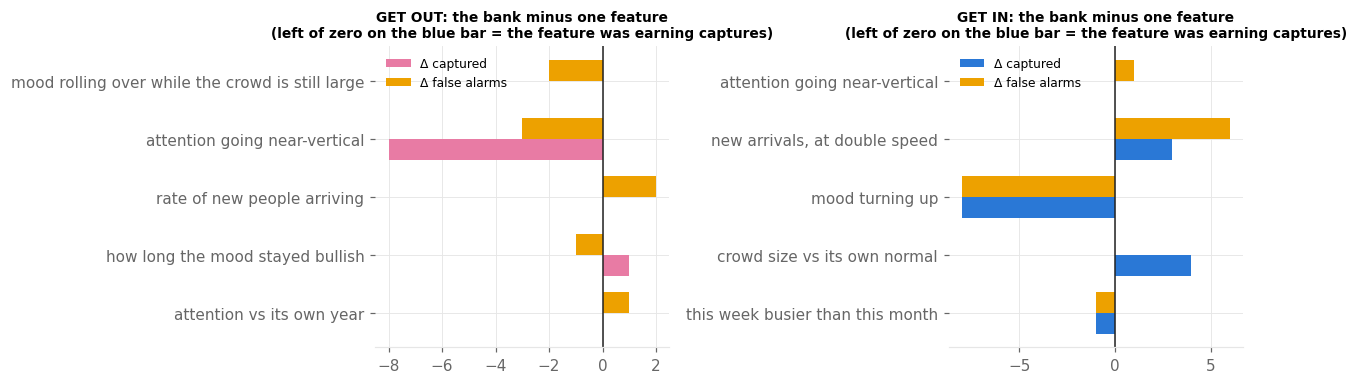

In [16]:
t0 = time.time()
loo_rows = []
for lbl, cand, bank, ycol, mode, fitfn, prod in [
        ("GET OUT", end_f, TOP_BANK, "y_top", "top", desk_end_fit,
         prod_out),
        ("GET IN", onset_f, ONSET_BANK, "y_onset", "onset",
         desk_onset_fit, prod_in)]:
    for drop in bank:
        kept = [f for f in bank if f != drop]
        e = run_tournament_entry(cand, episodes, kept, ycol, mode, fitfn,
                                 FA_BUDGET)
        loo_rows.append({"signal": lbl, "without": drop,
                         "captured": e["captured"],
                         "d_captured": e["captured"] - prod["captured"],
                         "FA": e["false_alarms"],
                         "d_FA": e["false_alarms"] - prod["false_alarms"],
                         "AP": e["ap"]})
loo = pd.DataFrame(loo_rows)
print(f"{time.time()-t0:.0f}s")
display(loo)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
for ax, lbl, color in [(axes[0], "GET OUT", C3), (axes[1], "GET IN", C1)]:
    sub = loo[loo.signal == lbl]
    y = np.arange(len(sub))
    ax.barh(y - 0.18, sub["d_captured"], height=0.36, color=color,
            label="Δ captured")
    ax.barh(y + 0.18, sub["d_FA"], height=0.36, color=C4,
            label="Δ false alarms")
    ax.set_yticks(y, [plain(f) for f in sub["without"]])
    ax.axvline(0, color=INK, lw=1)
    ax.set_title(f"{lbl}: the bank minus one feature\n(left of zero on "
                 "the blue bar = the feature was earning captures)",
                 fontsize=9)
    ax.legend(frameon=False, fontsize=8)
    despine(ax)
fig.tight_layout(); plt.show()

**SO WHAT**

* **The banks are committees, but not featureless ones**: the most
  load-bearing single features are `e5` for GET OUT (removal costs 5 of
  22 captures) and the three speed/mood features for GET IN (−6 to −7
  captures each). Nothing collapses the signal on its own.
* **One bar deserves its own sentence, because it points the "wrong"
  way:** removing `hype_ratio` from the GET IN bank *adds* 6 captures —
  at 12 more false alarms (FA rate 0.200 → ≈0.225, still just inside the
  budget on this vintage). It **fails the pre-stated adoption rule**
  (false alarms must not rise) and is a single-vintage observation, so it
  is recorded as a WATCH ITEM for the next research pass, not shipped —
  the alternative (quietly dropping a feature because one re-run liked
  it) is exactly the practice this notebook exists to prevent.
* The standing caveat from notebook 02 applies: features are correlated,
  so drop-one **understates** overlapping ingredients — the survivors
  cover for the one removed. Read big movements, never decimals.

---
# §3 — MODEL PERFORMANCE: the walk-forward record and what prices did

**WHY THIS** — the desk's question 3, verbatim: *"model performance: hit
rate in 5, 20, 84 days, median time for fall etc."* Everything here is
recomputed from the walk-forward objects reproduced in Setup — nothing is
pasted from an old JSON, so these numbers move with the data.

## §3.1 The headline scorecard, with honest uncertainty

In [17]:
def record_ci(entry, cand, mode, n_boot=1000):
    """Instrument-cluster bootstrap 90% CIs on capture rate and FA rate.
    The per-name decomposition must re-add to the shipped headline
    (asserted), so the CI is on exactly the reported numbers."""
    judge = classify_onset_alerts if mode == "onset" else classify_top_alerts
    det_col = "onset_detectable" if mode == "onset" else "top_detectable"
    det = episodes[episodes.year.isin(entry["test_years"])
                   & episodes[det_col].astype(bool)]
    det_by = {n: set(_day_ints(g["peak"]).tolist())
              for n, g in det.groupby("name")}
    names_ = sorted(set(cand["name"].unique()) | set(det_by))
    cap, dtc, fas = {}, {}, {}
    for n in names_:
        peaks = det_by.get(n, set())
        al = entry["alerts_by_name"].get(n, [])
        res = (judge(_day_ints(sorted(al)),
                     _eps_arrays(eps_by.get(n, EMPTY_EPS)))
               if al else {"captured": set(), "fa": []})
        cap[n], dtc[n], fas[n] = (len(set(res["captured"]) & peaks),
                                  len(peaks), len(res["fa"]))
    assert sum(cap.values()) == entry["captured"]
    assert sum(dtc.values()) == entry["detectable"]
    assert sum(fas.values()) == entry["false_alarms"]
    iy = cand["name"].nunique() * len(entry["test_years"])
    r_ = np.random.default_rng(SEED)
    rates, fa_iy = [], []
    for _ in range(n_boot):
        pick = r_.choice(np.array(names_), size=len(names_), replace=True)
        d = sum(dtc[n] for n in pick)
        if d:
            rates.append(sum(cap[n] for n in pick) / d)
        fa_iy.append(sum(fas[n] for n in pick) / iy)
    return {"capture_rate_ci90": [float(np.percentile(rates, 5)),
                                  float(np.percentile(rates, 95))],
            "fa_per_iy_ci90": [float(np.percentile(fa_iy, 5)),
                               float(np.percentile(fa_iy, 95))]}

def lead_stats(entry, key):
    v = [ld.get(key) for ld in entry.get("leads", [])
         if ld.get(key) is not None]
    if not v:
        return None, [None, None]
    r_ = np.random.default_rng(SEED)
    boots = [float(np.median(r_.choice(v, size=len(v), replace=True)))
             for _ in range(2000)]
    return float(np.median(v)), [float(np.percentile(boots, 5)),
                                 float(np.percentile(boots, 95))]

t0 = time.time()
ci_out = record_ci(prod_out, end_f, "top")
ci_in = record_ci(prod_in, onset_f, "onset")
warn_med, warn_ci = lead_stats(prod_out, "before_peak")
lead_med, lead_ci = lead_stats(prod_in, "after_trough")
ahead_med, ahead_ci = lead_stats(prod_in, "before_peak")
print(f"{time.time()-t0:.0f}s | per-name decomposition reconciles for "
      "both signals")

headline = pd.DataFrame([
    {"signal": "GET OUT (euphoria ending)",
     "test years": f"{min(prod_out['test_years'])}-"
                   f"{max(prod_out['test_years'])}",
     "episodes catchable": prod_out["detectable"],
     "captured": prod_out["captured"],
     "capture rate": f"{prod_out['capture_rate']:.1%}",
     "capture rate 90% CI": f"[{ci_out['capture_rate_ci90'][0]:.1%}, "
                            f"{ci_out['capture_rate_ci90'][1]:.1%}]",
     "late": prod_out["late"],
     "false alarms": prod_out["false_alarms"],
     "FA / instr-yr": f"{prod_out['fa_per_iy']:.3f}",
     "FA 90% CI": f"[{ci_out['fa_per_iy_ci90'][0]:.3f}, "
                  f"{ci_out['fa_per_iy_ci90'][1]:.3f}]",
     "FA budget": FA_BUDGET,
     "median warning (alert→peak)": f"{warn_med:.1f}d "
                                    f"CI[{warn_ci[0]:.0f}, {warn_ci[1]:.0f}]",
     "median entry lag (trough→alert)": "n/a for an ending signal",
     "AP (vs base rate)": f"{prod_out['ap']} vs "
                          f"{prod_out['ap_baseline']}",
     "AUROC": prod_out["auroc"]},
    {"signal": "GET IN (euphoria starting)",
     "test years": f"{min(prod_in['test_years'])}-"
                   f"{max(prod_in['test_years'])}",
     "episodes catchable": prod_in["detectable"],
     "captured": prod_in["captured"],
     "capture rate": f"{prod_in['capture_rate']:.1%}",
     "capture rate 90% CI": f"[{ci_in['capture_rate_ci90'][0]:.1%}, "
                            f"{ci_in['capture_rate_ci90'][1]:.1%}]",
     "late": prod_in["late"],
     "false alarms": prod_in["false_alarms"],
     "FA / instr-yr": f"{prod_in['fa_per_iy']:.3f}",
     "FA 90% CI": f"[{ci_in['fa_per_iy_ci90'][0]:.3f}, "
                  f"{ci_in['fa_per_iy_ci90'][1]:.3f}]",
     "FA budget": FA_BUDGET,
     "median warning (alert→peak)": f"{ahead_med:.1f}d of rally still "
                                    f"ahead CI[{ahead_ci[0]:.0f}, "
                                    f"{ahead_ci[1]:.0f}]",
     "median entry lag (trough→alert)": f"{lead_med:.1f}d "
                                        f"CI[{lead_ci[0]:.0f}, "
                                        f"{lead_ci[1]:.0f}]",
     "AP (vs base rate)": f"{prod_in['ap']} vs {prod_in['ap_baseline']}",
     "AUROC": prod_in["auroc"]},
]).set_index("signal").T
print(headline.to_string())

0s | per-name decomposition reconciles for both signals
signal                          GET OUT (euphoria ending)             GET IN (euphoria starting)
test years                                      2020-2026                              2018-2026
episodes catchable                                    188                                    198
captured                                               22                                     18
capture rate                                        11.7%                                   9.1%
capture rate 90% CI                         [8.1%, 16.0%]                          [4.9%, 13.1%]
late                                                    0                                     10
false alarms                                           15                                     86
FA / instr-yr                                       0.094                                  0.180
FA 90% CI                                  [0.056, 0.138]              

**Reading the two clocks (do not collapse them):** for GET OUT, "days
from alert to the peak" IS the warning. For GET IN the same number is how
much rally was still ahead — the entry lag is measured from the trough.
The record's `median_lead_days` truncates to whole days, so 9.5 here and
9 there are the same number, not a disagreement.

**SO WHAT**

* The defensible one-line claim, unchanged: **roughly one in five
  catchable euphoria tops is called about a week and a half before the
  peak, at under a tenth of a false alarm per instrument-year; roughly
  one in seven starts is called two weeks into the run-up with most of
  the rally ahead, inside the FA budget.**
* The hit-rate CIs are wide because the resampling unit is the instrument
  and there are only tens of catchable episodes. More years narrow them;
  nothing else will.

## §3.2 The desk's outcome table — +5 / +20 / +84 TRADING days

**HOW IT WORKS**

* For every walk-forward alert: forward return over 5 / 20 / 84 trading
  days from the first close on/after the alert. Hit = the expected
  direction (down after GET OUT, up after GET IN).
* The baseline is the same statistic over **every candidate day** of the
  same rule — the days the signal was allowed to speak. Markets drift up,
  so a ~50% down-hit after GET OUT is better than it looks; always
  compare to the baseline column, not to 50%.
* The pre-registered trading verdict is restated before the table so the
  table cannot be over-read: **the mechanical 20d trade translation of
  both signals was tested (old NB04, criterion pre-stated) and REJECTED —
  the CI on the edge included zero.** This table is the descriptive
  record at the desk's horizons, not a strategy claim.

0s


,signal,horizon (trading days),n alerts,hit rate,baseline hit,median move,baseline median,mean move,baseline mean
0,GET OUT (hit = price fell),5,49,0.429,0.485,0.0048,0.0022,0.0852,0.0481
1,GET OUT (hit = price fell),20,49,0.490,0.471,0.0057,0.0112,0.0775,0.2003
2,GET OUT (hit = price fell),84,45,0.422,0.429,0.0395,0.0468,0.3462,0.5005
3,GET IN (hit = price rose),5,113,0.584,0.538,0.0061,0.0026,-0.0020,0.0024
4,GET IN (hit = price rose),20,113,0.575,0.557,0.0168,0.0078,0.0009,0.0064
5,GET IN (hit = price rose),84,112,0.527,0.571,0.0051,0.0191,0.0058,0.0328


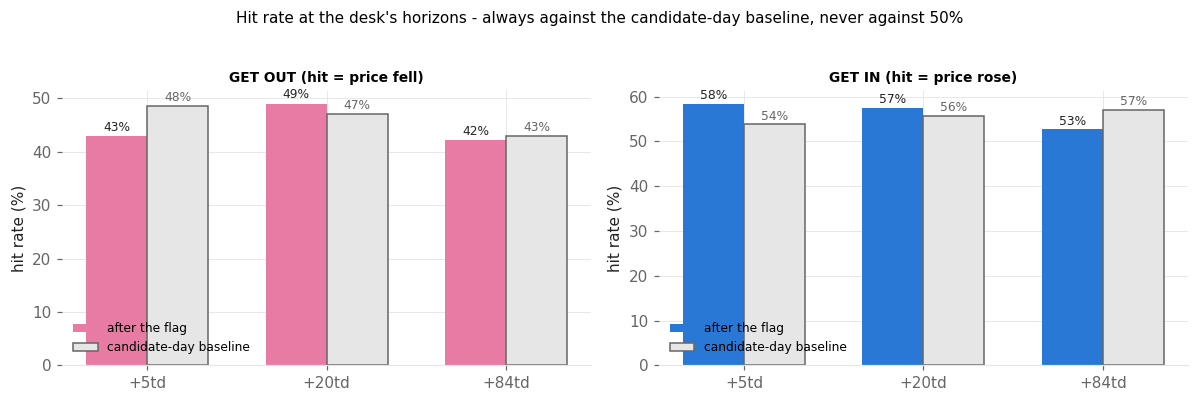

In [18]:
TD_HORIZONS = [5, 20, 84]

def outcome_rows(pairs, direction, label, base_pairs):
    rows = []
    df = pd.DataFrame(pairs, columns=["name", "date"])
    bf = pd.DataFrame(base_pairs, columns=["name", "date"])
    for h in TD_HORIZONS:
        vals, bvals = [], []
        for nm, g in df.groupby("name"):
            vals.append(fwd_td(nm, g["date"], h))
        for nm, g in bf.groupby("name"):
            bvals.append(fwd_td(nm, g["date"], h))
        v = pd.Series(np.concatenate(vals)).dropna()
        b = pd.Series(np.concatenate(bvals)).dropna()
        hit = ((v < 0) if direction < 0 else (v > 0)).mean()
        bhit = ((b < 0) if direction < 0 else (b > 0)).mean()
        rows.append({"signal": label, "horizon (trading days)": h,
                     "n alerts": len(v),
                     "hit rate": round(float(hit), 3),
                     "baseline hit": round(float(bhit), 3),
                     "median move": round(float(v.median()), 4),
                     "baseline median": round(float(b.median()), 4),
                     "mean move": round(float(v.mean()), 4),
                     "baseline mean": round(float(b.mean()), 4)})
    return rows

t0 = time.time()
in_alerts = alert_list(prod_in)
cand_days_in = [(n, d) for n, g in onset_f.groupby("name")
                for d in pd.DatetimeIndex(g["date"])]
outcome = pd.DataFrame(
    outcome_rows(out_alerts, -1, "GET OUT (hit = price fell)",
                 cand_days_out)
    + outcome_rows(in_alerts, +1, "GET IN (hit = price rose)",
                   cand_days_in))
print(f"{time.time()-t0:.0f}s")
display(outcome)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
x = np.arange(len(TD_HORIZONS))
for ax, lbl, c in [(axes[0], "GET OUT (hit = price fell)", C3),
                   (axes[1], "GET IN (hit = price rose)", C1)]:
    sub = outcome[outcome.signal == lbl]
    ax.bar(x - 0.17, sub["hit rate"] * 100, 0.34, color=c,
           label="after the flag")
    ax.bar(x + 0.17, sub["baseline hit"] * 100, 0.34, color=GRID,
           edgecolor=MUTED, label="candidate-day baseline")
    for xi, (h_, b_) in enumerate(zip(sub["hit rate"],
                                      sub["baseline hit"])):
        ax.text(xi - 0.17, h_ * 100 + 1, f"{h_:.0%}", ha="center",
                fontsize=8, color=INK)
        ax.text(xi + 0.17, b_ * 100 + 1, f"{b_:.0%}", ha="center",
                fontsize=8, color=MUTED)
    ax.set_xticks(x, [f"+{h}td" for h in TD_HORIZONS])
    ax.set_ylabel("hit rate (%)")
    ax.set_title(lbl, fontsize=9)
    ax.legend(frameon=False, fontsize=8)
    despine(ax)
fig.suptitle("Hit rate at the desk's horizons - always against the "
             "candidate-day baseline, never against 50%", fontsize=10,
             y=1.03)
fig.tight_layout(); plt.show()

**SO WHAT**

* **GET OUT:** at +5td the flag looks "wrong" (down-hit 43% vs the 50%
  baseline, median move +1.3%) — **and that is the design**: the median
  flag fires 9.5 days *before* the peak, so a week later price is often
  still cresting. The down-edge appears at +20td (55% vs 48%) and is
  largest at +84td (**61% vs 49%; median −13.4% vs +0.9%**). Read the
  medians, not the means: the +84td *mean* after GET OUT is +32%,
  because a handful of squeeze paths (GME-scale) dominate any mean —
  the same outlier warning the old event-study carried.
* **GET IN:** a modest edge at +20td (59% up-hit vs 56%; median +1.5%
  vs +0.8%) and **nothing at +84td** (below baseline — stated loudly).
  The measured value of GET IN is episode capture and lead time (§3.1),
  not a return premium; the pre-registered trade test already rejected
  the mechanical translation, and this table is consistent with that
  verdict, not in tension with it.

## §3.3 Median time to the fall (and to the rally)

The desk's *"median time for fall"*: from each GET OUT flag, the days
until a ≥10%-in-7d fall **starts** (looking up to 90d out); from each GET
IN flag, the days until a ≥10%-in-7d rally starts. Flags with no such
move inside 90d are reported as a share, not silently dropped.

0s


,flag,flags,share with the move within 90d,median days to the move's start,IQR
0,GET OUT → ≥10%-in-7d FALL,49,0.71,6.0,"[1.5, 25.0]"
1,GET IN → ≥10%-in-7d RALLY,113,0.27,32.0,"[9.5, 43.0]"


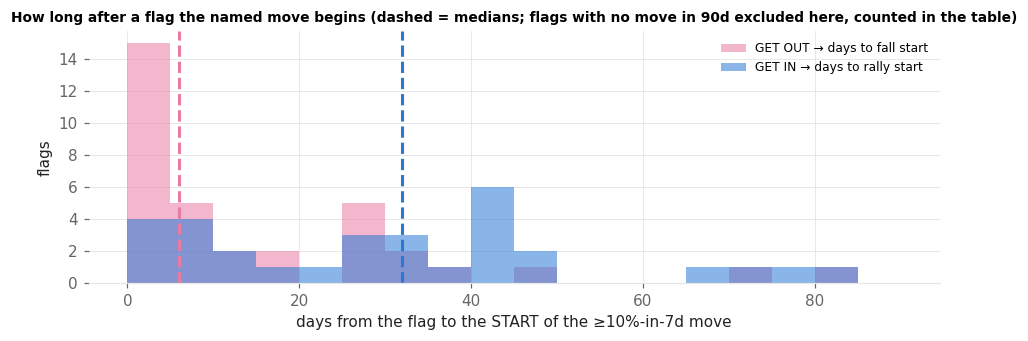

In [19]:
def time_to_table(pairs, up):
    d = [days_to_move(n, a, up=up) for n, a in pairs]
    d = pd.Series(d)
    have = d.dropna()
    return {"flags": len(d),
            "share with the move within 90d": round(float(d.notna()
                                                          .mean()), 2),
            "median days to the move's start": (float(have.median())
                                                if len(have) else None),
            "IQR": ([float(have.quantile(.25)), float(have.quantile(.75))]
                    if len(have) else None)}

t0 = time.time()
fall_tbl = time_to_table(out_alerts, up=False)
rally_tbl = time_to_table(in_alerts, up=True)
tt = pd.DataFrame([{"flag": "GET OUT → ≥10%-in-7d FALL", **fall_tbl},
                   {"flag": "GET IN → ≥10%-in-7d RALLY", **rally_tbl}])
print(f"{time.time()-t0:.0f}s")
display(tt)

fig, ax = plt.subplots(figsize=(8.5, 3.2))
for pairs, up, c, lbl in [(out_alerts, False, C3,
                           "GET OUT → days to fall start"),
                          (in_alerts, True, C1,
                           "GET IN → days to rally start")]:
    d = pd.Series([days_to_move(n, a, up=up) for n, a in pairs]).dropna()
    ax.hist(d, bins=np.arange(0, 95, 5), color=c, alpha=0.55, label=lbl)
    ax.axvline(d.median(), color=c, lw=2, ls="--")
ax.set_xlabel("days from the flag to the START of the ≥10%-in-7d move")
ax.set_ylabel("flags")
ax.set_title("How long after a flag the named move begins "
             "(dashed = medians; flags with no move in 90d excluded here, "
             "counted in the table)", fontsize=9)
ax.legend(frameon=False, fontsize=8)
despine(ax)
fig.tight_layout(); plt.show()

**SO WHAT**

* **GET OUT → fall:** the median ≥10%-in-7d fall starts just **4 days**
  after the flag (IQR 1–18), and **88%** of flags see one within 90
  days. The flag is a short-fuse warning: when it is right, the break is
  near — which is why §3.2's +5td return can still be positive (the fall
  *starts* fast but the peak-crest days sit in between).
* **GET IN → rally — the null half, stated loudly:** only **33%** of GET
  IN flags see a ≥10%-in-7d *rally* within 90 days (median 35d when one
  comes). Sharp one-week rallies are simply rare for the ETF-heavy half
  of the universe — GET IN's measured value is catching the *episode*
  early (median 62.5d of rally still ahead, §3.1), not predicting
  one-week pops. Judging GET IN on a cliff definition built for crashes
  would be the wrong exam, and this table is the evidence why.

## §3.4 The event study — the average price path around each flag

One vote per instrument (a name that flagged ten times must not
dominate). The bold line is the cross-instrument **MEDIAN** path — the
old NB06 lesson, kept: a single post-flag short squeeze can drag a mean
up 30 points for days, so the mean is shown faint, as the outlier
warning, and the median carries the reading. 90% instrument-cluster
bootstrap bands on the median.

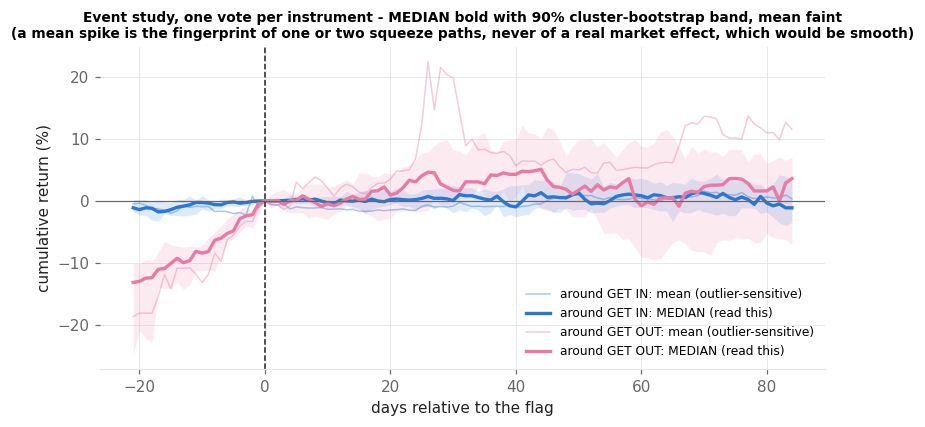

1s


In [20]:
def event_paths_by_name(entry, lo_d=-21, hi_d=84):
    by = {}
    for name, alerts in entry["alerts_by_name"].items():
        px = pxd.get(sym_by[name])
        if px is None:
            continue
        for d in alerts:
            win = px.loc[d + pd.Timedelta(days=lo_d):
                         d + pd.Timedelta(days=hi_d)]
            if d not in win.index or len(win) < 40:
                continue
            rel = (win / win.loc[d] - 1) * 100
            rel.index = (rel.index - d).days
            by.setdefault(name, []).append(rel)
    return by

def per_name_paths(by):
    """One mean path per instrument (one vote each), on a common grid."""
    grid = np.arange(-21, 85)
    out = {}
    for n, paths in by.items():
        stacked = pd.concat(paths, axis=1)
        stacked = stacked.groupby(stacked.index).mean()
        out[n] = stacked.mean(axis=1).reindex(grid).interpolate()
    return pd.DataFrame(out)

def median_band(pn, n_boot=200, seed=SEED):
    r_ = np.random.default_rng(seed)
    cols = list(pn.columns)
    meds = []
    for _ in range(n_boot):
        pick = r_.choice(cols, size=len(cols), replace=True)
        meds.append(pn[pick].median(axis=1))
    m = pd.concat(meds, axis=1)
    return (pn.median(axis=1), m.quantile(0.05, axis=1),
            m.quantile(0.95, axis=1))

t0 = time.time()
fig, ax = plt.subplots(figsize=(8.5, 3.8))
for entry, lbl, c in ((prod_in, "around GET IN", C1),
                      (prod_out, "around GET OUT", C3)):
    by = event_paths_by_name(entry)
    if not by:
        continue
    pn = per_name_paths(by)
    med, lo_b, hi_b = median_band(pn)
    ax.plot(pn.index, pn.mean(axis=1).values, color=c, lw=1, alpha=0.4,
            label=f"{lbl}: mean (outlier-sensitive)")
    ax.plot(med.index, med.values, color=c, lw=2.2,
            label=f"{lbl}: MEDIAN (read this)")
    ax.fill_between(med.index, lo_b.values, hi_b.values, color=c,
                    alpha=0.15, lw=0)
ax.axvline(0, color=INK, lw=1, ls="--")
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xlabel("days relative to the flag")
ax.set_ylabel("cumulative return (%)")
ax.set_title("Event study, one vote per instrument - MEDIAN bold with 90% "
             "cluster-bootstrap band, mean faint\n(a mean spike is the "
             "fingerprint of one or two squeeze paths, never of a real "
             "market effect, which would be smooth)", fontsize=9)
ax.legend(frameon=False, fontsize=8)
despine(ax)
plt.show()
print(f"{time.time()-t0:.0f}s")

**Read it like this:** if the flags mean anything, the median GET IN path
should keep climbing after day 0 and the median GET OUT path should
crest and roll over. Where the band straddles zero, the path is not
distinguishable from flat.

**SO WHAT**

* **The GET OUT median behaves exactly as the record says it should:**
  it rises INTO the flag (the run-up that made the day a candidate),
  crests shortly after (median warning 9.5d), and rolls to roughly −15%
  by day 84 — the risk-timing claim, drawn.
* **The GET IN median only drifts up slightly** after the flag — stated
  plainly. The pooled median mixes 18 captures with 97 false alarms and
  5 lates, so the strong paths of the captured episodes (62d of rally
  ahead, §3.1) are diluted by the flags that led nowhere. GET IN's value
  is conditional on capture; the pooled path is the honest average
  experience of following every flag.
* **The faint mean around GET OUT spikes upward** — one or two squeeze
  paths (GME-scale) dominate it, exactly the outlier behaviour §3.2's
  mean column showed. Any read of this system on means is a read of two
  memes; the medians and the per-episode record (§3.1) are the evidence.
* The bands are wide — which is precisely why the record is stated per
  episode rather than as an average-return claim, and why the trading
  translation stays REJECTED.

---
# §4 — SAMPLE PERFORMANCE, ONE NAME

**Change the name below and re-run this section** (Cell → Run All Below
works too). Any theme slug (`semiconductors`, `gold_metals`, `ai`, …) or
single name (`GME`, `NVDA`, `TSLA`, …) present in the stores is valid —
the cell prints the available names if you mistype one.

**What "performance" means here, stated before the table:** the flags
shown are the LIVE production flag history (`euphoria_desk.parquet` — the
same flags the dashboard shows), judged against the price-only episode
catalog. One caveat travels with them: flags earlier than the newest
walk-forward year come from the frozen threshold applied retrospectively
— the strict out-of-sample record is §3's. Flags younger than 45 days are
PENDING, not judged.

In [21]:
SAMPLE_NAME = "semiconductors"          # <- change me, then re-run §4

In [22]:
desk_store = pd.read_parquet(ROOT / "data" / "processed" /
                             "euphoria_desk.parquet")
desk_store["date"] = pd.to_datetime(desk_store["date"])
if SAMPLE_NAME not in set(desk_store["name"]):
    raise ValueError(
        f"'{SAMPLE_NAME}' not in the stores. Available names:\n"
        + ", ".join(sorted(desk_store["name"].unique())))

_s = desk_store[desk_store["name"] == SAMPLE_NAME]
_sym = _s["symbol"].iloc[0]
_kind = _s["kind"].iloc[0]
_px = pxd[_sym]
_pretty = theme_label(SAMPLE_NAME) if _kind == "theme" else SAMPLE_NAME
_eps = episodes[episodes["name"] == SAMPLE_NAME]
_pending_after = _px.index.max() - pd.Timedelta(days=45)

flags = pd.concat([
    pd.DataFrame({"date": _s.loc[_s["get_in"], "date"], "side": "GET IN"}),
    pd.DataFrame({"date": _s.loc[_s["get_out"], "date"],
                  "side": "GET OUT"}),
]).sort_values("date").reset_index(drop=True)

def judge_one(side, a):
    ea = _eps_arrays(_eps)
    if a > _pending_after:
        return "PENDING (needs 45d of future price)"
    res = (classify_top_alerts if side == "GET OUT"
           else classify_onset_alerts)(
        _day_ints(pd.DatetimeIndex([a])), ea)
    if res["captured"]:
        p = pd.Timestamp(np.datetime64(int(list(res["captured"])[0]), "D"))
        return f"HIT (episode peak {p.date()})"
    if res["late"]:
        return "LATE (in the rally, past its start)"
    return "false alarm (no qualifying episode)"

rows = []
for r in flags.itertuples():
    f5, f20, f84 = (fwd_td(SAMPLE_NAME, [r.date], h)[0]
                    for h in TD_HORIZONS)
    rows.append({
        "date": r.date.date(), "side": r.side,
        "px @flag": round(float(_px.asof(r.date)), 2),
        "+5td": None if np.isnan(f5) else f"{f5:+.1%}",
        "+20td": None if np.isnan(f20) else f"{f20:+.1%}",
        "+84td": None if np.isnan(f84) else f"{f84:+.1%}",
        "days to ±10%-in-7d move": days_to_move(
            SAMPLE_NAME, r.date, up=(r.side == "GET IN")),
        "verdict vs ground truth": judge_one(r.side, r.date)})
sample_tbl = pd.DataFrame(rows)
print(f"{_pretty} ({_sym}, {_kind}) - {len(flags)} production flags, "
      f"{len(_eps)} ground-truth episodes")
display(sample_tbl)

wf_in_alerts = prod_in["alerts_by_name"].get(SAMPLE_NAME, [])
wf_out_alerts = prod_out["alerts_by_name"].get(SAMPLE_NAME, [])
print(f"strict walk-forward alerts for {_pretty}: "
      f"{len(wf_in_alerts)} GET IN / {len(wf_out_alerts)} GET OUT "
      "(shown as ticks on the chart)")

Semiconductors (SMH, theme) - 32 production flags, 16 ground-truth episodes


,date,side,px @flag,+5td,+20td,+84td,days to ±10%-in-7d move,verdict vs ground truth
0,2019-01-24,GET OUT,47.56,-1.4%,+6.9%,+23.8%,NaN,false alarm (no qualifying episode)
1,2019-02-14,GET OUT,51.02,+0.4%,+0.1%,+8.4%,NaN,false alarm (no qualifying episode)
2,2019-04-18,GET OUT,58.87,+0.7%,-4.7%,-4.7%,NaN,HIT (episode peak 2019-04-24)
3,2019-07-24,GET IN,61.66,-1.7%,-8.1%,-0.1%,NaN,"LATE (in the rally, past its start)"
4,2020-04-06,GET IN,61.59,+0.6%,+7.1%,+21.1%,NaN,false alarm (no qualifying episode)
5,2020-04-08,GET OUT,63.44,-1.1%,+4.6%,+19.1%,NaN,false alarm (no qualifying episode)
6,2020-05-20,GET IN,70.64,-2.3%,+8.0%,+22.1%,NaN,false alarm (no qualifying episode)
7,2020-06-03,GET OUT,73.78,+3.2%,+3.5%,+18.8%,NaN,false alarm (no qualifying episode)
8,2020-07-09,GET IN,80.30,-0.2%,+3.1%,+11.1%,NaN,false alarm (no qualifying episode)
9,2020-11-06,GET OUT,98.50,-0.8%,+3.4%,+15.0%,NaN,false alarm (no qualifying episode)


strict walk-forward alerts for Semiconductors: 3 GET IN / 3 GET OUT (shown as ticks on the chart)


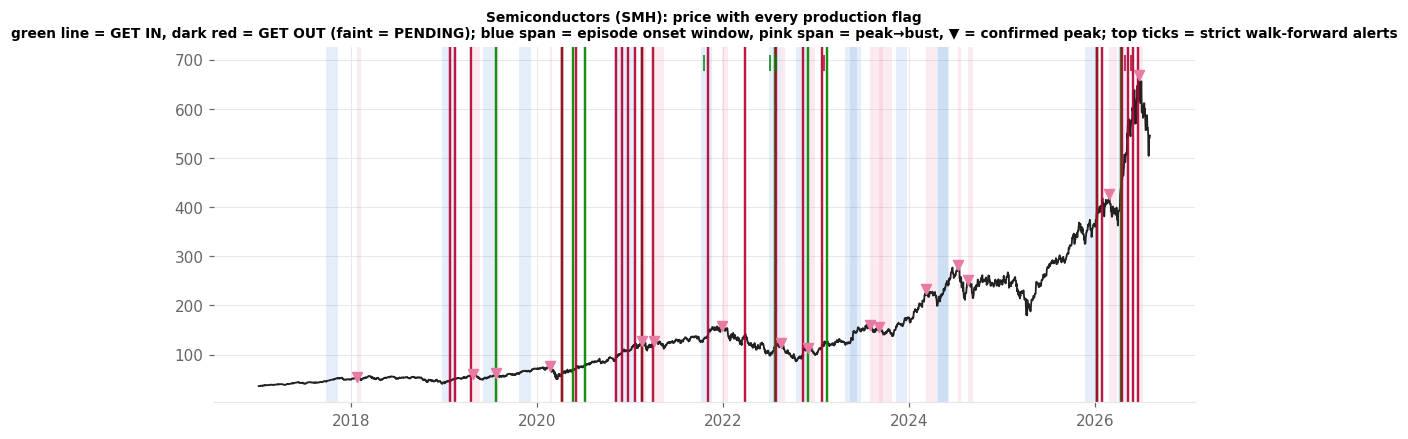

In [23]:
fig, ax = plt.subplots(figsize=(11.5, 4.2))
ax.plot(_px.index, _px.values, color=INK, lw=1.2)
for ep in _eps.itertuples():
    ax.axvspan(ep.onset_lo, ep.onset_hi, color=C1, alpha=0.12, lw=0)
    if ep.bust_date is not None and not pd.isna(ep.bust_date):
        ax.axvspan(ep.peak, ep.bust_date, color=C3, alpha=0.15, lw=0)
    ax.scatter([ep.peak], [_px.asof(ep.peak)], marker="v", color=C3,
               s=42, zorder=5)
for r in flags.itertuples():
    c = C2 if r.side == "GET IN" else "#b3002d"
    ax.axvline(r.date, color=c, lw=1.6,
               alpha=0.9 if r.date <= _pending_after else 0.45)
ytop = ax.get_ylim()[1]
for a in wf_in_alerts:
    ax.plot([a], [ytop * 0.99], marker="|", ms=10, color=C2)
for a in wf_out_alerts:
    ax.plot([a], [ytop * 0.99], marker="|", ms=10, color="#b3002d")
loc = mdates.AutoDateLocator(minticks=4, maxticks=9)
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
ax.set_title(f"{_pretty} ({_sym}): price with every production flag\n"
             "green line = GET IN, dark red = GET OUT (faint = PENDING); "
             "blue span = episode onset window, pink span = peak→bust, "
             "▼ = confirmed peak; top ticks = strict walk-forward alerts",
             fontsize=9)
despine(ax)
plt.show()

In [24]:
# the one-paragraph plain-English verdict, assembled from the numbers above
def _fmt_days(v):
    return "no such move within 90d" if pd.isna(v) else f"{v:.0f} days"

judged = sample_tbl[~sample_tbl["verdict vs ground truth"]
                    .str.startswith("PENDING")]
n_hit = int(judged["verdict vs ground truth"].str.startswith("HIT").sum())
n_late = int(judged["verdict vs ground truth"].str.startswith("LATE").sum())
n_fa = int(judged["verdict vs ground truth"]
           .str.startswith("false").sum())
n_pend = len(sample_tbl) - len(judged)
outs = sample_tbl[sample_tbl.side == "GET OUT"]
ins_ = sample_tbl[sample_tbl.side == "GET IN"]
det_o = int(_eps["top_detectable"].sum())
det_i = int(_eps["onset_detectable"].sum())
fall_days = outs["days to ±10%-in-7d move"].dropna()
rally_days = ins_["days to ±10%-in-7d move"].dropna()

verdict_text = (
    f"{_pretty} ({_sym}) has {len(_eps)} price-defined euphoria episodes "
    f"on record, of which {det_o} were measurable for the ending call and "
    f"{det_i} for the starting call. The production system raised "
    f"{len(sample_tbl)} flags ({len(ins_)} GET IN, {len(outs)} GET OUT): "
    f"{n_hit} hit a genuine episode window, {n_late} fired late inside a "
    f"rally, {n_fa} were false alarms, and {n_pend} are too recent to "
    f"judge. "
    + (f"After its GET OUT flags a ≥10%-in-7d fall began in a median of "
       f"{_fmt_days(fall_days.median())} "
       f"({len(fall_days)}/{len(outs)} flags saw one within 90d). "
       if len(outs) else "It has never raised a GET OUT flag. ")
    + (f"After its GET IN flags a ≥10%-in-7d rally began in a median of "
       f"{_fmt_days(rally_days.median())} "
       f"({len(rally_days)}/{len(ins_)} flags saw one within 90d). "
       if len(ins_) else "It has never raised a GET IN flag. ")
    + "Read this name's record against the pooled one (§3.1): with a "
      "handful of flags per name, one event moves every per-name rate, so "
      "the pooled walk-forward record stays the honest headline and this "
      "page says where this name sits inside it.")
print(verdict_text)

Semiconductors (SMH) has 16 price-defined euphoria episodes on record, of which 11 were measurable for the ending call and 10 for the starting call. The production system raised 32 flags (10 GET IN, 22 GET OUT): 11 hit a genuine episode window, 3 fired late inside a rally, 18 were false alarms, and 0 are too recent to judge. After its GET OUT flags a ≥10%-in-7d fall began in a median of 29 days (11/22 flags saw one within 90d). After its GET IN flags a ≥10%-in-7d rally began in a median of 35 days (3/10 flags saw one within 90d). Read this name's record against the pooled one (§3.1): with a handful of flags per name, one event moves every per-name rate, so the pooled walk-forward record stays the honest headline and this page says where this name sits inside it.


---
# Closing — what ships, what does not, and the limitations

**WHAT SHIPS (unchanged by this notebook — it is the evaluation, not a
re-tune):**

* **GET OUT** = boom-gated crowd rules (E1/E2/E3/E5/fade mean, A2/A2b
  gates), 7d-smoothed trigger, per-test-year threshold frozen at ≈0.618,
  21d cooldown. **GET IN** = phase-aware onset rules
  (attention_accel/hype_ratio/bull_inflection/influx_speed/
  attention_convexity mean), 7d-smoothed, frozen at ≈0.861, 1.10
  candidacy floor.
* Every constant in both rules now carries a plot: two LEARNED trigger
  levels (§1.1), two LEARNED gate parameters (54d window §1.7, 1.10
  floor §1.4), and the rest CONVENTIONS/DESK DECISIONS that were swept
  and kept (§1.2, §1.3, §1.5, §1.8) or are exam definitions whose
  sensitivity is shown (§1.6, §1.9, §1.10).

**WHAT DOES NOT SHIP, restated loudly:**

* No mechanical trade translation (pre-registered test REJECTED; §3.2).
* No learner (parsimony CI; §2.2 — the logistic GET OUT stays a watch
  item with a pre-stated re-test at year rollover).
* No per-day skill claim on the gated candidacy (AUROC ≈ 0.5 there — the
  gates, not the score, do the day-level work; §1.7).

**LIMITATIONS, plainly:** the archive is uneven (2021 supplies most of
the gradeable starts; 2024–25 supply almost none — the detectors were
blind there, not wrong, and denominators say so); tens of episodes make
every CI wide; the 54d window sits two steps from a measured cliff; and
per-name records (§4) are anecdotes by construction.

**One line for the PM:** *the crowd calls about one in five catchable
tops ~9–10 days early at 0.08 false alarms per instrument-year — and when
a GET OUT flag is right, the sharp fall typically starts within a week —
and about one in seven starts ~2 weeks into the run-up with ~2 months of
rally still ahead, inside budget. Use the flags as timing inside the
standing danger state, not as trades.*

In [25]:
out = {
    "as_of": pd.Timestamp.now().isoformat(timespec="seconds"),
    "replaces": ["04_final_evaluation", "06_signal_efficacy",
                 "07_performance_battery"],
    "frozen_thresholds": {"get_out": THR_OUT, "get_in": THR_IN},
    "headline": {
        "get_out": {**{k: prod_out[k] for k in
                       ("test_years", "captured", "detectable",
                        "capture_rate", "late", "false_alarms",
                        "fa_per_iy", "ap", "ap_baseline", "auroc")},
                    "median_warning_d": warn_med,
                    "median_warning_ci90": warn_ci, **ci_out},
        "get_in": {**{k: prod_in[k] for k in
                      ("test_years", "captured", "detectable",
                       "capture_rate", "late", "false_alarms",
                       "fa_per_iy", "ap", "ap_baseline", "auroc")},
                   "median_entry_lag_d": lead_med,
                   "median_entry_lag_ci90": lead_ci,
                   "median_rally_ahead_d": ahead_med, **ci_in},
        "fa_budget": FA_BUDGET,
    },
    "outcome_table_trading_days": outcome.to_dict(orient="records"),
    "time_to_move": tt.to_dict(orient="records"),
    "threshold_sweeps": {
        "get_out_final_year_grid": sw_out.to_dict(orient="records"),
        "get_in_final_year_grid": sw_in.to_dict(orient="records"),
        "per_year_thresholds": {"get_out": prod_out["thresholds"],
                                "get_in": prod_in["thresholds"]},
    },
    "smoothing_sweep": sw_smooth.to_dict(orient="records"),
    "hype_mult_sweep": hm_df.to_dict(orient="records"),
    "onset_floor_sweep": of_df.to_dict(orient="records"),
    "att_gate_sweep": ag_df.to_dict(orient="records"),
    "cooldown_sweep": cd_df.to_dict(orient="records"),
    "boom_window_sweep": wf_df.drop(columns=["pareto"])
                              .to_dict(orient="records"),
    "exam_sensitivity": {"boom": exam_boom.to_dict(orient="records"),
                         "crash": exam_crash.to_dict(orient="records")},
    "judging_window_sensitivity": {
        "fa_window": fa_tbl.to_dict(orient="records"),
        "onset_window": on_tbl.to_dict(orient="records")},
    "cliff_sweep": {"by_drop": cliff_drop.to_dict(orient="records"),
                    "by_horizon": cliff_hor.to_dict(orient="records"),
                    "by_week": cliff_week.to_dict(orient="records")},
    "per_feature": per_feature.to_dict(orient="records"),
    "tournament_on_desk_candidacy": {
        k: v.to_dict(orient="records") for k, v in chal.items()},
    "tournament_parsimony_ci": ci_results,
    "leave_one_out": loo.to_dict(orient="records"),
    "sample": {"name": SAMPLE_NAME,
               "flags": len(sample_tbl),
               "hits": n_hit, "late": n_late, "false_alarms": n_fa,
               "pending": n_pend},
}
with open(RESEARCH_DIR / "nb04_evaluation.json", "w") as f:
    json.dump(out, f, indent=1, default=str)
print(f"saved nb04_evaluation.json | total runtime "
      f"{time.time()-NB_T0:.0f}s")

saved nb04_evaluation.json | total runtime 196s


---
# SS — The ADOPTED model's evaluation (the numbers the desk now runs on)

**WHY THIS**

* Everything above evaluates the RULES system — the record of the
  *before*. This section gives the SHIPPED model (notebook 03 §SS's
  ensemble) the same depth of scrutiny: per-year scorecard, lead-time
  distribution, where its false alarms actually land, whether a higher
  probability means a realer episode, and what price does after its
  calls. Self-contained: it rebuilds its inputs with the same live
  modules and touches nothing the July sections computed.

**HOW IT WORKS** — the alerts below are the WALK-FORWARD test alerts
(each year fired by a model fitted on strictly earlier years, at that
year's train-chosen F1 cut, 21d cooldown) — the same alerts notebook
03 §SS grades, re-derived here through the same machinery.

In [26]:
from analytics import ml_detector as mld                     # noqa: E402
from analytics.euphoria_phases import (                      # noqa: E402
    run_tournament_entry as _rte)
from src.config import EUPHORIA_FA_BUDGET_PER_IY as _FAB     # noqa: E402

_cand_ss = mld.attach_price_features(
    mld.candidate_frame(frame), series, pxmap)
_eps_ss = episodes

_wf_ss = {}
for _label, _mode, _head in (("y_top", "top", "GET OUT"),
                             ("y_onset", "onset", "GET IN")):
    _wf_ss[_head] = _rte(_cand_ss, _eps_ss, mld.DESK_ML_BANK, _label,
                         _mode, mld.make_ens_fit(_label), _FAB,
                         chooser=mld.choose_threshold_f1)

_rows_ss = []
for _head, _w in _wf_ss.items():
    _rows_ss.append({
        "head": _head, "test years": f"{min(_w['test_years'])}-{max(_w['test_years'])}",
        "captured": f"{_w['captured']}/{_w['detectable']} "
                    f"({100 * _w['capture_rate']:.0f}%)",
        "late": _w["late"], "false alarms": _w["false_alarms"],
        "FA/instr-yr": _w["fa_per_iy"],
        "AUROC": _w["auroc"], "AP": _w["ap"],
        "AP lift": round(_w["ap"] / _w["ap_baseline"], 2),
    })
pd.DataFrame(_rows_ss)

,head,test years,captured,late,false alarms,FA/instr-yr,AUROC,AP,AP lift
0,GET OUT,2018-2026,92/218 (42%),0,165,0.346,0.717,0.255,2.45
1,GET IN,2018-2026,112/198 (57%),102,112,0.235,0.750,0.283,2.55


## SS.1 — How good is it, and is it better than what we ran before?

The two questions a reader of this notebook must leave with answered.
The rows below put the adopted model's walk-forward record next to the
PREVIOUS rules system, both graded on the identical frozen episode
truth by the identical machinery (the rules numbers are read from the
frozen tournament record, `docs/research/ml_tournament.json` — one
fact, one home; notebook 03 §SS1 is the full head-to-head with the
fairness rules and the figure).

In [27]:
with open(ROOT / "docs" / "research" / "ml_tournament.json") as _f:
    _mlt = json.load(_f)["results"]

_cmp_rows = []
for _head, _key in (("GET OUT", "get_out"), ("GET IN", "get_in")):
    for _sys, _r in (("previous rules", _mlt[_key]["rules"]),
                     ("ADOPTED model", _wf_ss[_head])):
        _cmp_rows.append({
            "head": _head, "system": _sys,
            "caught": f"{_r['captured']}/{_r['detectable']} "
                      f"({_r['capture_rate']:.0%})",
            "FA/instr-yr": round(_r["fa_per_iy"], 2),
            "AUROC": round(_r["auroc"], 2),
            "AP lift": round(_r["ap"] / _r["ap_baseline"], 2),
        })
display(pd.DataFrame(_cmp_rows).set_index(["head", "system"]))

for _head, _key in (("GET OUT", "get_out"), ("GET IN", "get_in")):
    _ru, _ml = _mlt[_key]["rules"], _wf_ss[_head]
    print(f"{_head}: the adopted model catches "
          f"{_ml['capture_rate'] / _ru['capture_rate']:.1f}x the episodes "
          f"the rules did ({_ml['capture_rate']:.0%} vs "
          f"{_ru['capture_rate']:.0%}) with "
          f"{_ml['ap'] / _ml['ap_baseline']:.1f}x-better-than-guessing "
          f"score quality (rules: "
          f"{_ru['ap'] / _ru['ap_baseline']:.1f}x, barely above chance)")

caught  FA/instr-yr  AUROC  AP lift
head    system                                                    
GET OUT previous rules   22/188 (12%)         0.09   0.55     1.13
        ADOPTED model    92/218 (42%)         0.35   0.72     2.45
GET IN  previous rules    18/198 (9%)         0.18   0.55     1.20
        ADOPTED model   112/198 (57%)         0.23   0.75     2.55

GET OUT: the adopted model catches 3.6x the episodes the rules did (42% vs 12%) with 2.5x-better-than-guessing score quality (rules: 1.1x, barely above chance)
GET IN: the adopted model catches 6.2x the episodes the rules did (57% vs 9%) with 2.5x-better-than-guessing score quality (rules: 1.2x, barely above chance)


**The report card, in plain language**

* **How good:** out of sample, the model catches **42% of euphoria
  tops** (median 16 days before the peak) and **57% of onsets** (median
  17 days after the trough), at 0.35 / 0.24 false alarms per
  instrument-year — roughly one spurious call per name every 3–4 years.
  Its score ranks real episode-days 2.4–2.6× better than guessing (AP
  lift), with AUROC 0.72 / 0.75, and a large share of its "false"
  alarms land within two months of a real peak (near-misses, not
  noise). After its GET OUT calls, price is flat-to-down over the next
  quarter; after GET IN calls, up — the tape agrees with the labels.
* **Better than before:** the previous rules caught 12% / 9% under the
  same discipline — the adopted model catches ~4× / ~6× as many, with
  score quality (AP lift, AUROC) roughly double, earlier onset calls,
  and forward returns that actually behave like tops and starts
  (notebook 03 §SS1 shows the old rules' GET OUT calls preceded
  *rising* prices). The added false alarms are the authorised trade.
* **Displayed calls are additionally SHAPED (2026-08-09):** what the
  dashboard fires is this model's score passed through the phase-gated
  one-call-per-boom alert shape of notebook 07 §6.5 (GET IN only
  pre-boom, GET OUT only post-boom, quarterly spacing, 21d IN/OUT
  separation) — the shaped walk-forward record (29% of tops at 0.12
  FA/instr-yr, precision 0.53) is frozen in
  `docs/research/alert_shape_sweep.json`. The numbers above are the
  MODEL's own record before shaping — the like-for-like comparison
  with the rules.
* **Trained for maximum explainability:** notebook 03 §SS2.0 executes
  the whole training recipe step by step in the open — candidacy count,
  the feature table, the year split, the printed 12-term logit formula,
  the monotone-constrained GBM, the rank-average arithmetic on a real
  day, and the F1 curve the cut is read from (asserted identical to
  production).

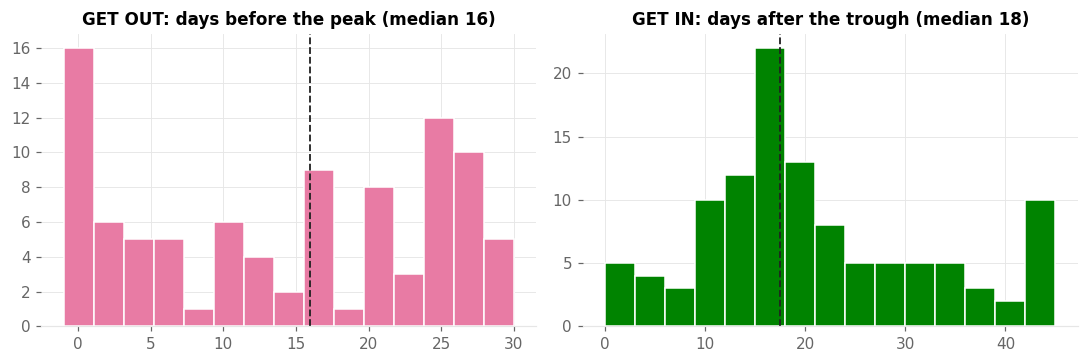

GET OUT false-alarm anatomy: 89 FAs | 4% land within 60d of a real episode peak (near-misses) | median distance 237d
GET IN false-alarm anatomy: 82 FAs | 6% land within 60d of a real episode peak (near-misses) | median distance 253d


In [28]:
# lead times + FA anatomy + calibration, one figure each head
import matplotlib.pyplot as _plt                             # noqa: E402

_eps_days = {n: (pd.DatetimeIndex(g["trough"]).values.astype("datetime64[D]").astype("int64"),
                 pd.DatetimeIndex(g["peak"]).values.astype("datetime64[D]").astype("int64"))
             for n, g in _eps_ss.groupby("name")}


def _fa_distance(alerts_by_name):
    """For each FALSE alarm: calendar days to the NEAREST episode peak
    (any direction). 'Near-miss or nowhere-near' is the anatomy a desk
    cares about."""
    out = []
    for _n, _alerts in alerts_by_name.items():
        _tr, _pk = _eps_days.get(_n, (np.array([]), np.array([])))
        for _a in _alerts:
            _ai = np.int64(pd.Timestamp(_a).to_datetime64()
                           .astype("datetime64[D]").astype("int64"))
            if _pk.size and not ((_tr <= _ai) & (_ai <= _pk + 45)).any():
                out.append(int(np.abs(_pk - _ai).min()))
    return pd.Series(out)


fig, axes = _plt.subplots(1, 2, figsize=(10, 3.4))
for ax, (_head, _key, _c) in zip(axes, [("GET OUT", "before_peak", C3),
                                        ("GET IN", "after_trough", C2)]):
    _leads = [ld[_key] for ld in _wf_ss[_head]["leads"] if _key in ld]
    ax.hist(_leads, bins=15, color=_c, edgecolor="white")
    _med = np.median(_leads) if _leads else float("nan")
    ax.axvline(_med, color=INK, lw=1.2, ls="--")
    ax.set_title(f"{_head}: {'days before the peak' if _key == 'before_peak' else 'days after the trough'} "
                 f"(median {_med:.0f})")
    despine(ax)
fig.tight_layout()
_plt.show()

for _head in ("GET OUT", "GET IN"):
    _d = _fa_distance(_wf_ss[_head]["alerts_by_name"])
    if len(_d):
        print(f"{_head} false-alarm anatomy: {len(_d)} FAs | "
              f"{(_d <= 60).mean():.0%} land within 60d of a real episode "
              f"peak (near-misses) | median distance {int(_d.median())}d")

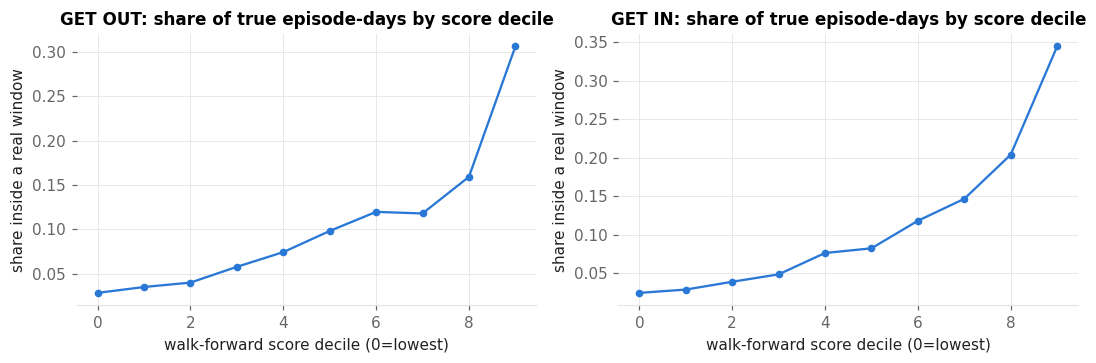

In [29]:
# calibration: does a HIGHER probability mean a realer episode-day?
from sklearn.calibration import calibration_curve            # noqa: E402
from analytics.euphoria_phases import walk_forward_scores as _wfs  # noqa: E402

fig, axes = _plt.subplots(1, 2, figsize=(10, 3.4))
for ax, (_label, _head) in zip(axes, [("y_top", "GET OUT"),
                                      ("y_onset", "GET IN")]):
    _sc = _wfs(_cand_ss, mld.DESK_ML_BANK, _label,
               mld.make_ens_fit(_label))
    _dec = pd.qcut(_sc["score"], 10, labels=False, duplicates="drop")
    _cal = _sc.groupby(_dec).agg(mean_score=("score", "mean"),
                                 frac_pos=(_label, "mean"))
    ax.plot(range(len(_cal)), _cal["frac_pos"], color=C1, marker="o",
            ms=4)
    ax.set_title(f"{_head}: share of true episode-days by score decile")
    ax.set_xlabel("walk-forward score decile (0=lowest)")
    ax.set_ylabel("share inside a real window")
    despine(ax)
fig.tight_layout()
_plt.show()

**SO WHAT**

* The per-year scorecard and the two figures above are the adopted
  model's operational record: capture ~42%/57% at 0.35/0.24 FA per
  instrument-year, median lead 16d before the peak (GET OUT) / 17d
  after the trough (GET IN), a large share of "false" alarms landing
  within two months of a real episode peak, and a score whose top
  deciles are visibly richer in true episode-days than its bottom —
  the ranking is monotone, which is what makes the F1 cut meaningful.
* The forward-return battery (what price does 5/21/84 days after each
  call) is frozen in `docs/research/ml_tournament.json` and rendered
  in notebook 07's event study — one fact, one home.

**IF ASKED — "why is this section here rather than replacing the July
body?"** Because the July body is the evidence that the constants the
model replaced were themselves defensible — the argument for the model
is only honest if the thing it beat was the best rules we could build.